# House Prices
## Data Science


Ce notebook constitue la **phase d’idéation** du cycle CRISP-ML pour le projet de régression immobilière sur les données Kaggle `House Prices - Advanced Regression Techniques`.

L’objectif ici est de :
- Comprendre les données
- Nettoyer et préparer les variables
- Explorer les relations clés
- Créer un modèle de régression linéaire de base
- Évaluer ses performances avec la métrique RMSLE

# 1. Compréhension de l'activité et des données

Le développement d'applications d'apprentissage automatique commence par l'identification du champ d'application de l'apprentissage automatique, des critères de réussite et d'une vérification de la qualité des données. L'objectif de cette première phase est d'assurer la faisabilité du projet.


In [ ]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from statsmodels.graphics.gofplots import qqplot

plt.style.use('seaborn-v0_8') # pretty matplotlib plots

In [ ]:
train_raw = pd.read_csv('train.csv', index_col = 'Id')
validation_raw = pd.read_csv('test.csv', index_col = 'Id')

## 1.1 Premier aperçu de l'ensemble de données


In [ ]:
train_raw.head()


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### The dependant variable

La première chose à faire est d'examiner notre variable cible, à savoir **SalePrice**. Nous allons devoir la prédire pour l'ensemble de données de test.

In [ ]:
# descriptive statistics summary
train_raw['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

This isn't very visual, but we can already see that the lower quartile is around 130k, the median at 163k, the mean at 180k and the upper quartile at 214k. This means the distribution is skewed.

Let's plot the distribution to have a look.

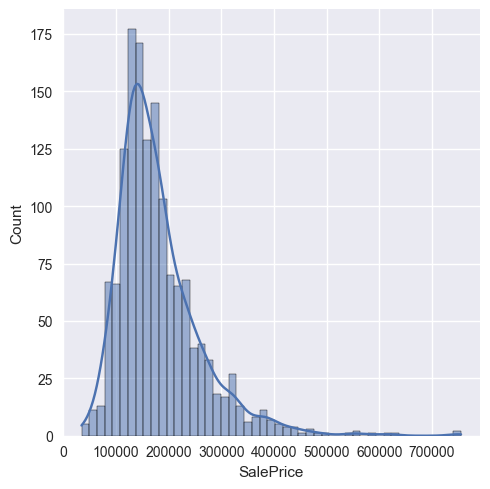

In [ ]:
# distribution plot with normal fit
ax = sns.displot(data = train_raw['SalePrice'], kde=True)
plt.show()

Nous pouvons voir que la distribution est complètement asymétrique. Effectuons un rapide test d'hypothèse pour confirmer qu'elle n'est pas normale.

Dans notre cas, l'hypothèse nulle stipule que la variable **Prix de vente** provient d'une population normalement distribuée. Nous devons effectuer le _test de Shapiro-Wilk__ afin de rejeter notre hypothèse nulle.

https://en.wikipedia.org/wiki/Shapiro%E2%80%93Wilk_test

The assocated p-value is : 3.2061412312021656e-33
With a threshold α = 0.05, we reject the null hypothesis


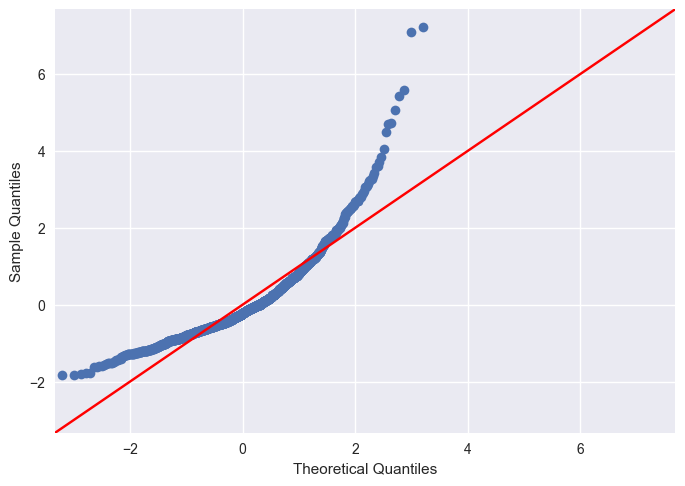

In [ ]:
# Shapiro-Wilk Test for normality together with the Q-Q plot
alpha = 0.05
W, p = stats.shapiro(train_raw['SalePrice'])

print('The assocated p-value is : ' + str(p))

if p < alpha : 
    print('With a threshold α = ' + str(alpha) + ', we reject the null hypothesis')
else : 
    print('With a threshold α = ' + str(alpha) + ', we fail to reject the null hypothesis')
    
qqplot(train_raw['SalePrice'], dist = stats.distributions.norm, fit = True, line = '45')
plt.show()

The assocated p-value is : 3.2061412312021656e-33
With a threshold α = 0.05, we reject the null hypothesis


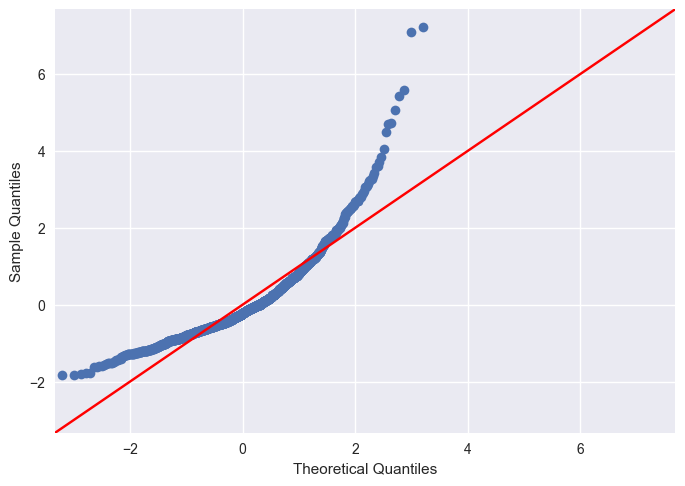

In [ ]:
# Shapiro-Wilk Test for normality together with the Q-Q plot
alpha = 0.05
W, p = stats.shapiro(train_raw['SalePrice'])

print('The assocated p-value is : ' + str(p))

if p < alpha : 
    print('With a threshold α = ' + str(alpha) + ', we reject the null hypothesis')
else : 
    print('With a threshold α = ' + str(alpha) + ', we fail to reject the null hypothesis')
    
qqplot(train_raw['SalePrice'], dist = stats.distributions.norm, fit = True, line = '45')
plt.show()

Le _test de Shapiro-Wilk__ ainsi que le **graphique Q-Q** confirment que la variable ne provient pas d'une population normalement distribuée.

https://en.wikipedia.org/wiki/Q%E2%80%93Q_plot

Sur Kaggle, il est dit que "_Les soumissions sont évaluées sur l'erreur quadratique moyenne (RMSE) entre le **logarithme** de la valeur prédite et le **logarithme** du prix de vente observé. (Le fait de prendre les logarithmes signifie que les erreurs de prédiction des maisons chères et des maisons bon marché affecteront le résultat de la même manière.

Voyons donc à quoi ressemble un ajustement log-normal !




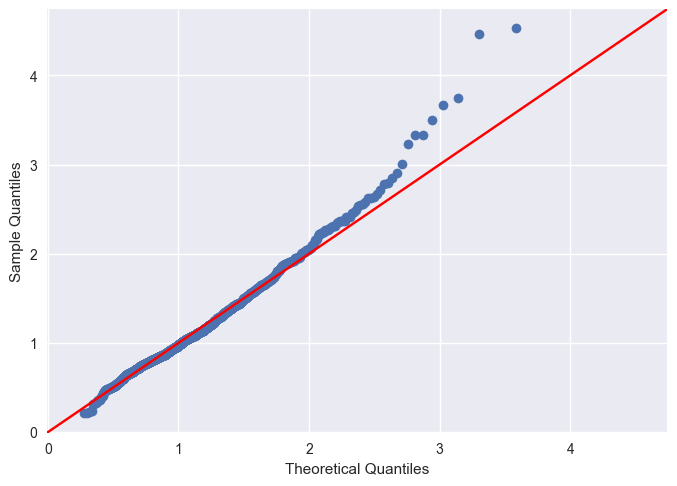

In [ ]:
qqplot(train_raw['SalePrice'], dist = stats.distributions.lognorm, fit = True, line = '45')
plt.show()

Ce n'est pas encore parfait. Voyez-vous ces valeurs extrêmes qui dévient en haut à droite ? Cependant, c'est déjà beaucoup mieux. Nous devrons probablement supprimer ces valeurs extrêmes, car les algorithmes de régression ne se comportent pas bien avec elles.

Transformons notre variable cible PrixVente à l'aide de la correspondance suivante

$$ x \mapsto \log(1 + x) $$

C'est exactement la fonction NumPy **log1p**. Nous écrivons le **logarithme de PrixVente** dans une variable dédiée **y**.

https://numpy.org/doc/stable/reference/generated/numpy.log1p.html




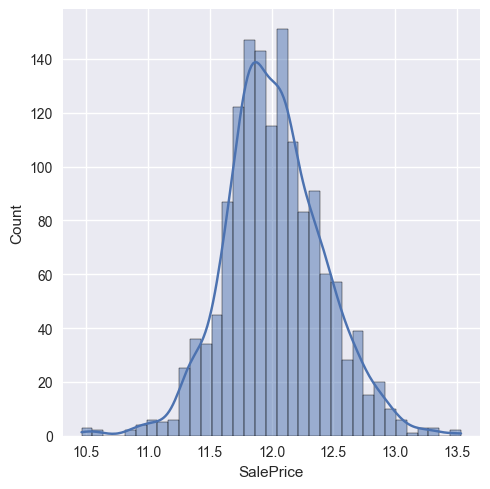

In [ ]:
# new variable target which is the logarithm of the SalePrice
target = np.log1p(train_raw['SalePrice'])

# distribution plot
ax = sns.displot(data = target, kde=True)
plt.show()

### Les variables indépendantes

Il est maintenant temps d'analyser les variables indépendantes et leur interaction avec le **Prix de vente**. Il est probable que nous devrons d'abord procéder à un nettoyage de base des données.

(￣o￣) . z Z

Si vous lisez attentivement la description des variables, vous verrez qu'il y a trois types de variables dans l'ensemble de données :

1. Qualitatives.
2. Quantitatives,
3. Date.

La documentation nous indique que les variables **OverallQual** et **OverallCond** sont qualitatives. Cependant, nous les considérerons comme des variables quantitatives puisqu'elles sont déjà représentées par des valeurs sur une échelle ordinale.

http://jse.amstat.org/v19n3/decock/DataDocumentation.txt



In [ ]:
qualitative = ['MSSubClass', 'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
              'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
              'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
              'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
              'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
              'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
              'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageFinish', 
              'GarageCars', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
              'SaleType', 'SaleCondition', 'MoSold']

quantitative = ['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'MasVnrArea', 'BsmtFinSF1',  
               'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 
               'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 
               'PoolArea', 'MiscVal']

date = ['YearBuilt', 'YearRemodAdd', 'YrSold', 'GarageYrBlt']

Afin de nettoyer entièrement les données, concaténons les **train_raw** avec les **test_raw**.

In [ ]:
data_raw = pd.concat([train_raw, validation_raw])

## 1.2 Imputing missing values

Examinons d'abord les variables manquantes. La fonction suivante permet de tracer le nombre de NA par colonne.

In [ ]:
def plot_missing(data):

    missing = data.isnull().sum()
    missing = missing[missing > 0]
    
    if missing.empty:
        print('No missing values')
    else :
        missing.sort_values(inplace=True)
        missing.plot.bar()
    
        plt.show()

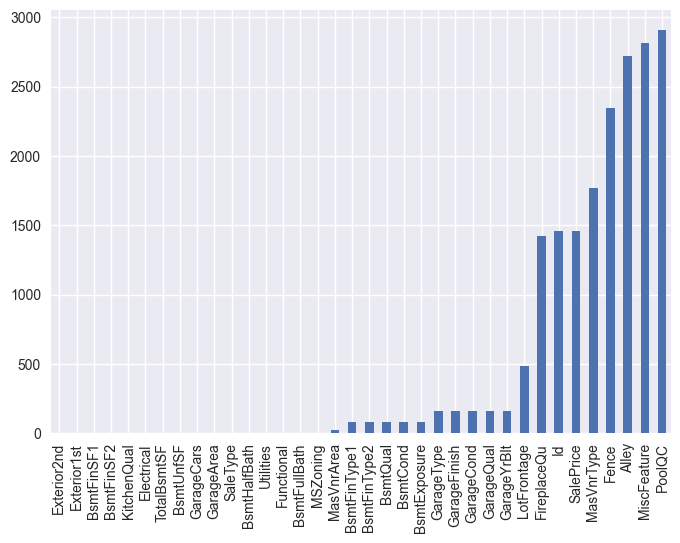

In [ ]:
plot_missing(data_raw)

Une analyse plus approfondie peut montrer que le **test.csv** contient plus de colonnes avec des valeurs manquantes. Par exemple, la variable **TotalBSMSF** n'a pas de valeurs manquantes dans l'ensemble de données d'apprentissage, alors qu'elle en a dans l'ensemble de données d'attente. C'est typique ! L'ensemble de données de formation est souvent plus propre que l'ensemble de données de production.

C'est une autre raison pour laquelle nous avons regroupé les ensembles de données. Il est plus facile de gérer ce type de phénomène pour l'analyse des données.

Nous allons maintenant définir une stratégie pour "combler les lacunes". Il est toujours bon de vérifier auprès de l'entreprise pourquoi il y a des valeurs manquantes ou anormales. La documentation révèle que les valeurs manquantes sont là pour une bonne raison, parce que la caractéristique n'existe pas.



### Quantitative variables

La stratégie la plus sensée consiste à remplir les blancs par des zéros, car une valeur manquante dans les données indique qu'il n'y en a pas.

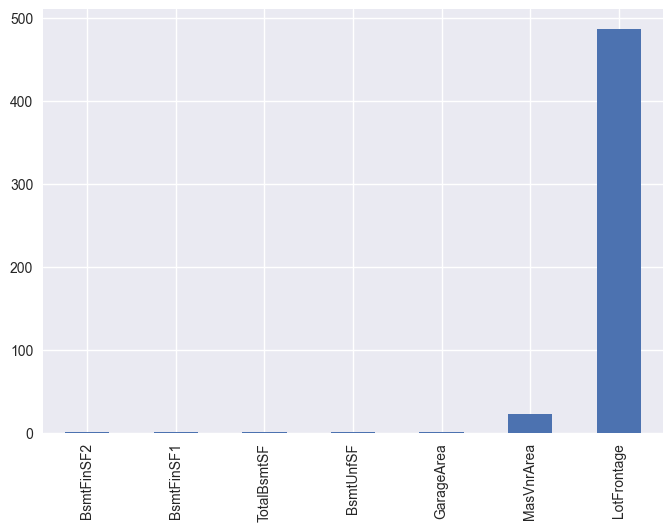

In [ ]:
plot_missing(data_raw[quantitative])

In [ ]:
# For quantitative variables, we will fill columns with 0
def fill_missing_with_constant(data, columns, constant):
    
    data_clean = data.copy()
    
    for c in columns :
        
        if data_clean[c].isnull().any():
            data_clean[c] = data_clean[c].fillna(constant)
    
    return data_clean

### Qualitative variables

La stratégie la plus judicieuse pour les variables qualitatives consiste à remplir les champs vides par la valeur "NA", comme on le ferait dans le domaine de la veille économique.

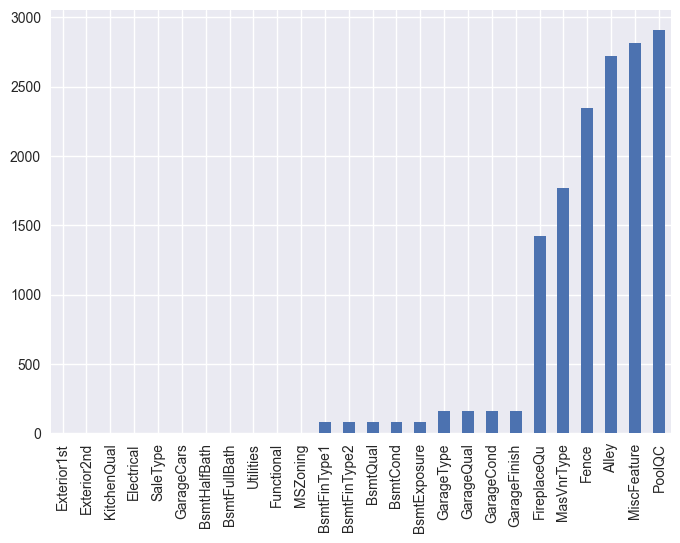

In [ ]:
plot_missing(data_raw[qualitative])

Nous n'avons pas besoin de définir une fonction particulière pour cela car nous utilisons la fonction **fill_missing_with_constant** définie précédemment.

### Date variables

Nous pouvons voir que la seule variable de date qui a des valeurs manquantes est **GarageYrBlt**, probablement parce que la maison n'a pas de garage. Remplaçons donc cette date par **YearBuilt**, ce qui est logique d'un point de vue commercial.

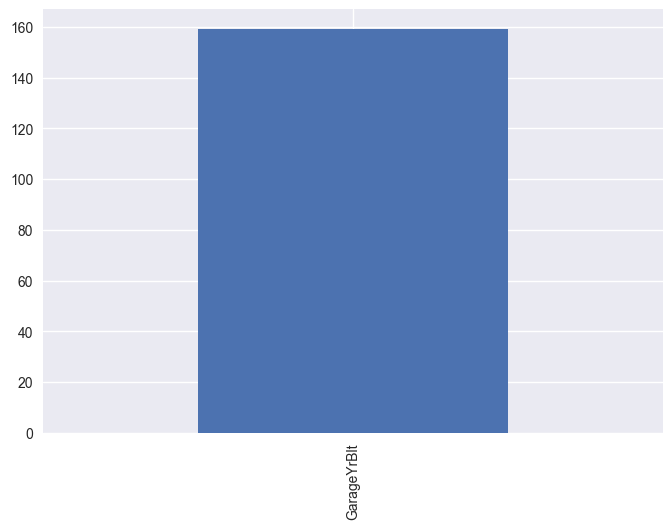

In [ ]:
plot_missing(data_raw[date])

In [ ]:
# For date variables, we will fill the missing values using the values from another column
def fill_missing_with_column(data, missing, column) :
    
    data_clean = data.copy()
    
    data_clean[missing] = np.where(data_clean[missing].isnull(), data_clean[column], data_clean[missing])
    
    return data_clean

## 1.3 Basic transform

Étant donné que les ventes s'échelonnent de 2006 à 2010, il serait logique de calculer le nombre d'années écoulées depuis que la maison a été construite, rénovée, etc.

In [ ]:
def compute_differences_to_year_sold(data) :
    
    data_clean = data.copy()
    
    data_clean['YearBuilt'] = data_clean['YrSold'] - data_clean['YearBuilt']
    data_clean['YearRemodAdd'] = data_clean['YrSold'] - data_clean['YearRemodAdd']
    data_clean['GarageYrBlt'] = data_clean['YrSold'] - data_clean['GarageYrBlt']
    
    return data_clean

## 1.4 Run the cleaning process
Nous allons maintenant procéder au nettoyage de l'ensemble des données et les explorer.

In [ ]:
def clean(data) :
    
    data_clean = data.copy()
    
    # imputing missing variables
    data_clean = fill_missing_with_constant(data_clean, columns = quantitative, constant = 0)
    data_clean = fill_missing_with_constant(data_clean, columns = qualitative, constant = 'NA')
    data_clean = fill_missing_with_column(data_clean, missing = ['GarageYrBlt'], column = ['YearBuilt'])

    # transform date columns
    data_clean = compute_differences_to_year_sold(data_clean)
    
    return data_clean

Lançons le processus de nettoyage.

In [ ]:
data_clean = clean(data_raw)

data_clean.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1.0,60,RL,65.0,8450,Pave,NA,Reg,Lvl,AllPub,...,0,NA,NA,NA,0,2,2008,WD,Normal,208500.0
1,2.0,20,RL,80.0,9600,Pave,NA,Reg,Lvl,AllPub,...,0,NA,NA,NA,0,5,2007,WD,Normal,181500.0
2,3.0,60,RL,68.0,11250,Pave,NA,IR1,Lvl,AllPub,...,0,NA,NA,NA,0,9,2008,WD,Normal,223500.0
3,4.0,70,RL,60.0,9550,Pave,NA,IR1,Lvl,AllPub,...,0,NA,NA,NA,0,2,2006,WD,Abnorml,140000.0
4,5.0,60,RL,84.0,14260,Pave,NA,IR1,Lvl,AllPub,...,0,NA,NA,NA,0,12,2008,WD,Normal,250000.0


## 1.5 Exploratory Data Understanding

Nous allons maintenant procéder à l'AED et réfléchir à la manière dont nous allons résoudre ce cas. Nous avons deux types de variables, les variables catégorielles et les variables numériques. En outre, nous devons diviser notre ensemble de données nettoyé en un ensemble de données de formation et un ensemble de données de validation, comme auparavant.

In [ ]:
categorical = ['MSSubClass', 'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
               'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
               'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
               'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
               'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
               'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 
               'KitchenQual','TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 
               'GarageFinish', 'GarageCars', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 
               'MiscFeature', 'SaleType', 'SaleCondition', 'YrSold', 'MoSold']

numeric = ['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'MasVnrArea', 'BsmtFinSF1',
           'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 
           'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 
           'PoolArea', 'MiscVal', 'YearBuilt', 'YearRemodAdd', 'GarageYrBlt']

# Split of the clean dataset into train & validation
train_clean = data_clean[data_clean.index.isin(train_raw.index)]
validation_clean = data_clean[data_clean.index.isin(validation_raw.index)]

### Analyse des variables numériques

Regardons d'abord les variables numériques. Il est assez classique de regarder la corrélation entre chaque variable numérique avec notre variable cible, c'est-à-dire le **logarithme de SalePrice**. Attention à ne pas faire de corrélation avec le **Prix de vente** lui-même, car le lien n'est probablement pas linéaire comme nous l'avons vu précédemment.

In [ ]:
def correlation(y, X, features, method = 'pearson'):
    
    cor = pd.DataFrame()
    cor['feature'] = features
    
    cor['correlation_coef'] = [X[f].corr(y, method = method) for f in features]
    cor['correlation_coef'] = cor['correlation_coef'].fillna(0)
    
    cor = cor.sort_values('correlation_coef', ascending = False)

    plt.figure(figsize=(10, 0.25*len(features)))
    sns.barplot(data = cor, y = 'feature', x = 'correlation_coef', orient = 'h')
    
    return cor

Regardons ensuite les corrélations entre les variables numériques et le **logarithme de SalePrice** sur l'ensemble de données train_clean.

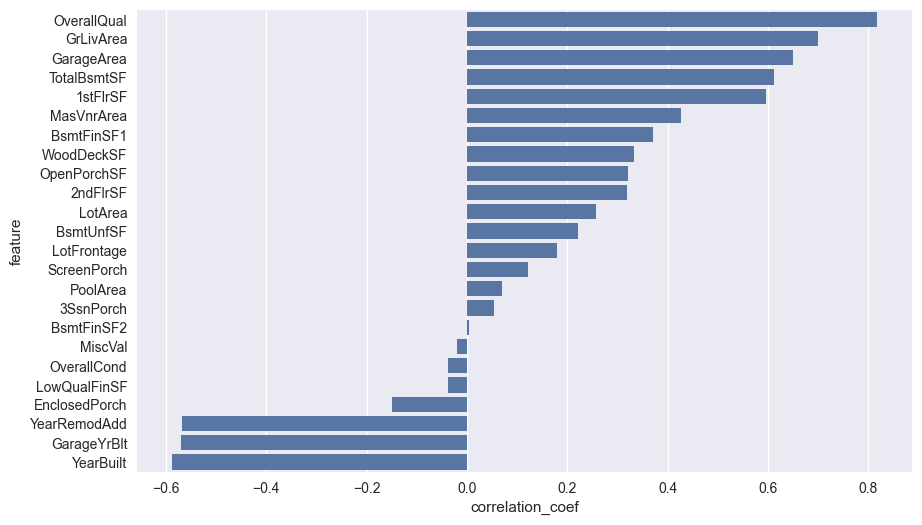

In [ ]:
cor = correlation(target, train_clean, numeric, method = 'pearson')

La valeur de corrélation elle-même peut être trompeuse, il faut tracer des diagrammes de dispersion. Traçons tous les diagrammes de dispersion pour ces caractéristiques numériques.

In [ ]:
def scatter_plots(y, X, features) :
    
    for f in features :
        x = X[f]
        
        plt.title('Correlation ' + y.name + ' & ' + x.name)
        sns.regplot(x = x.name, y = y.name, data = pd.concat([x, y], axis = 1), x_jitter = .05)
        
        plt.show()

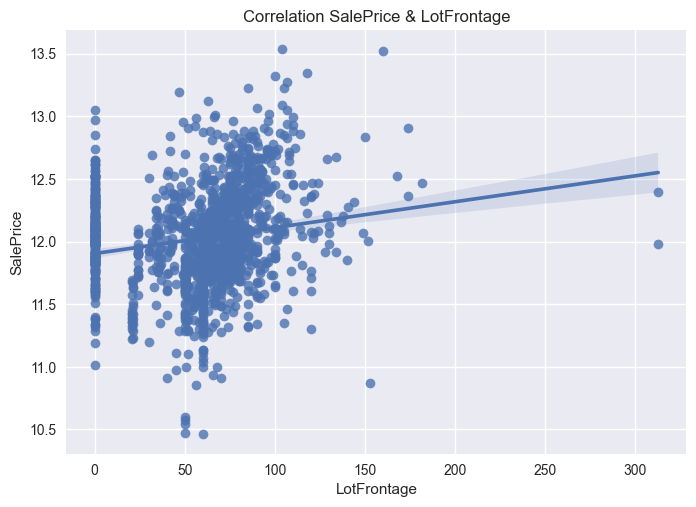

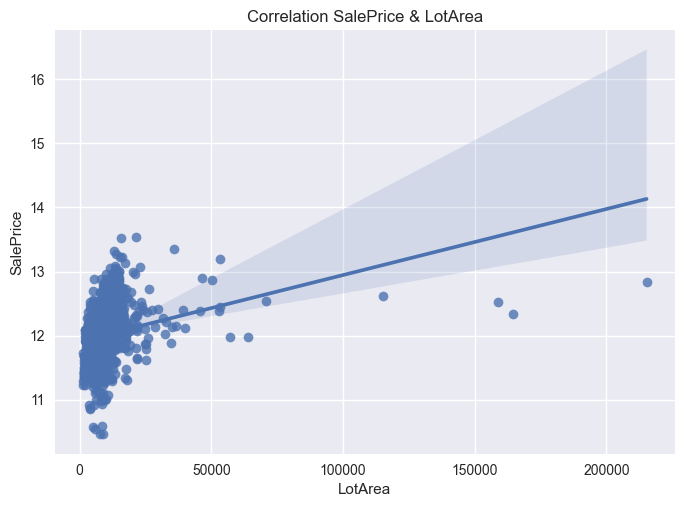

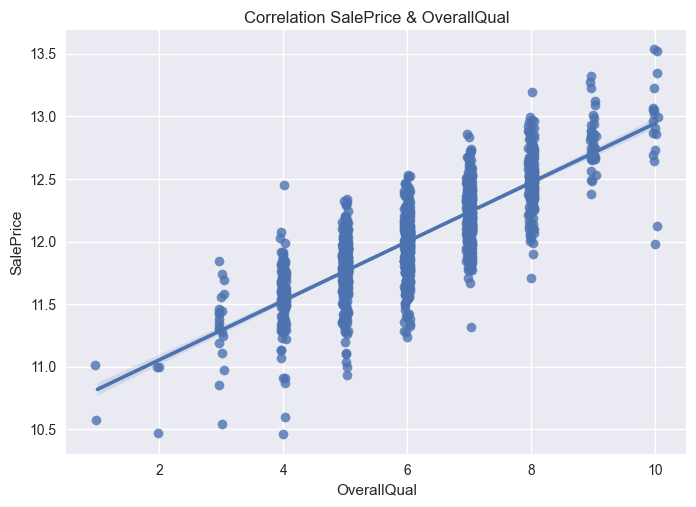

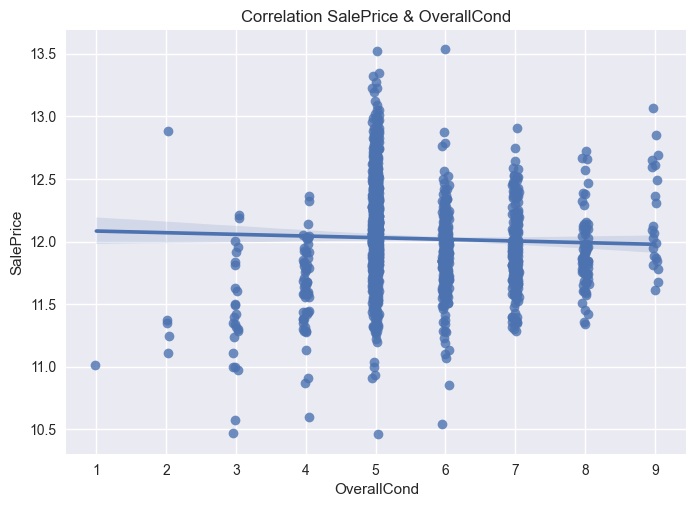

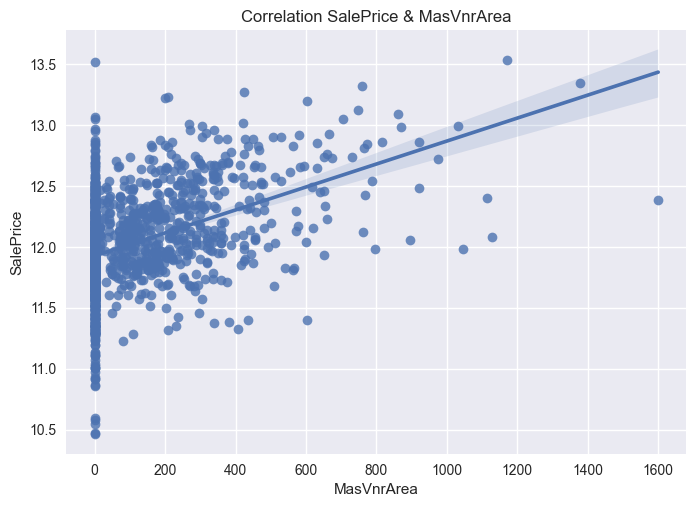

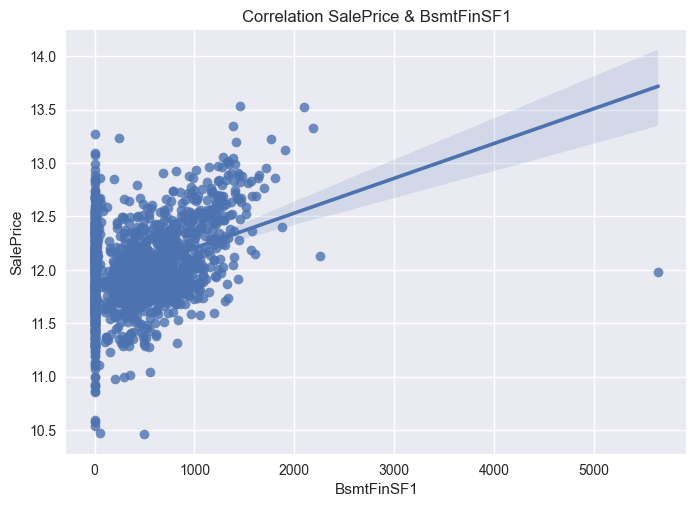

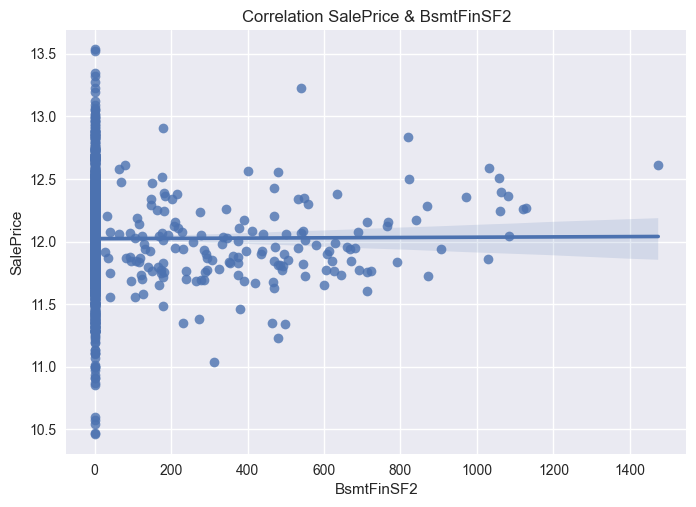

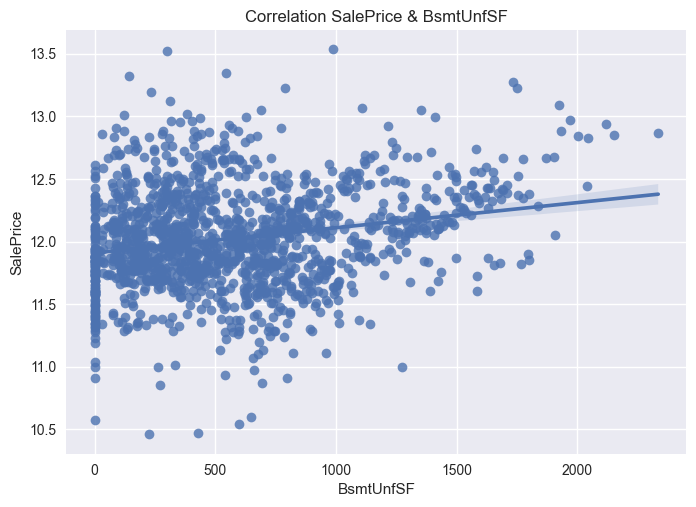

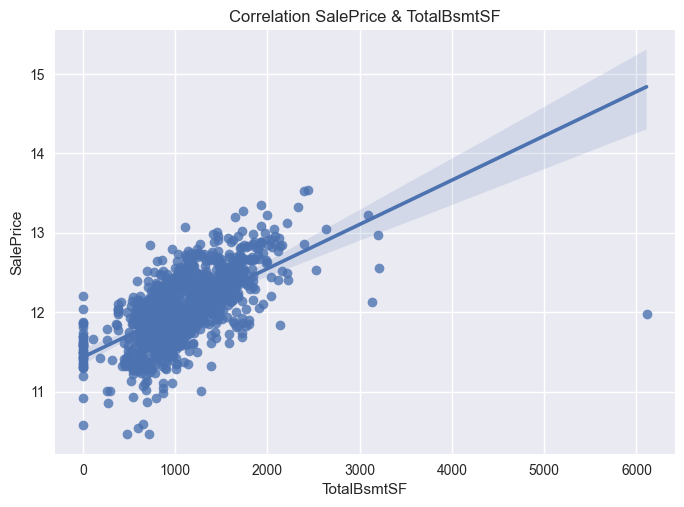

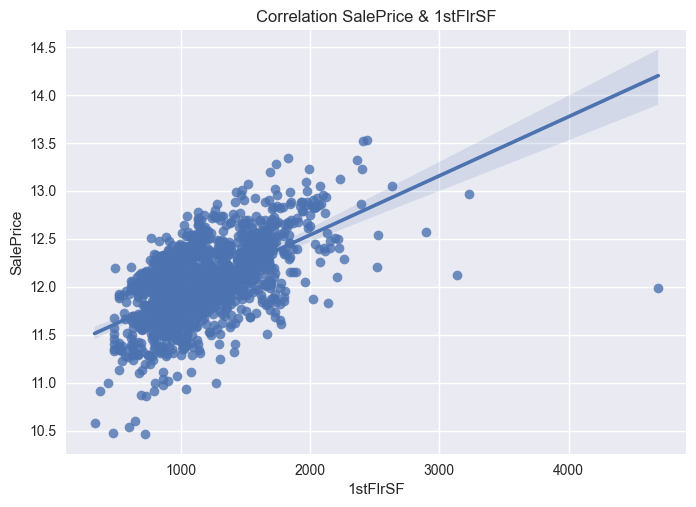

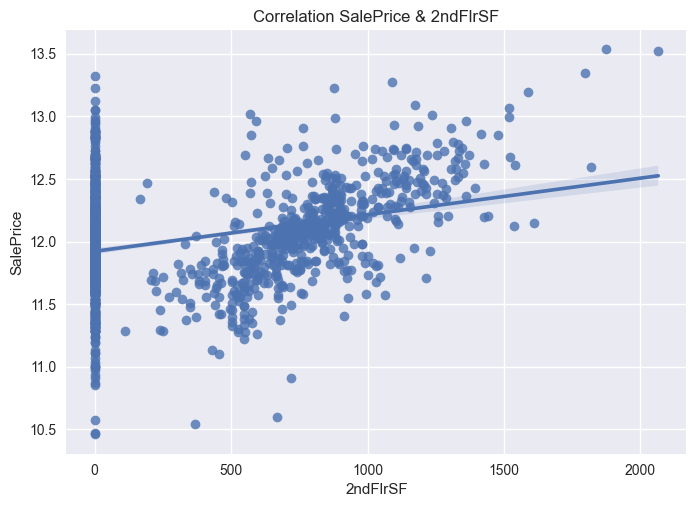

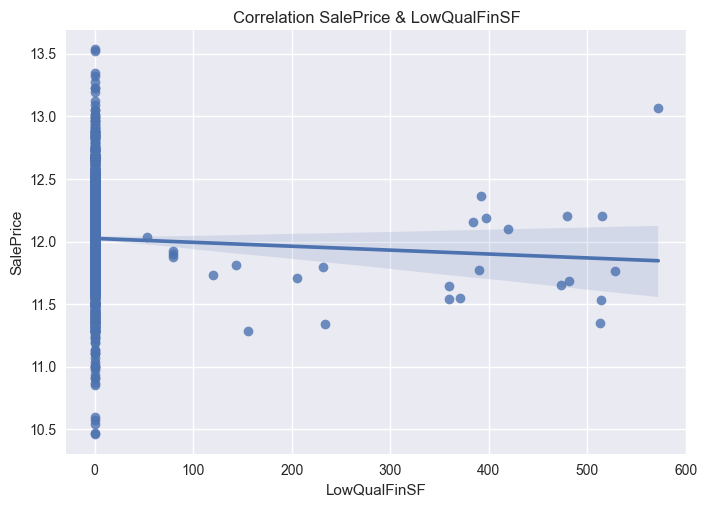

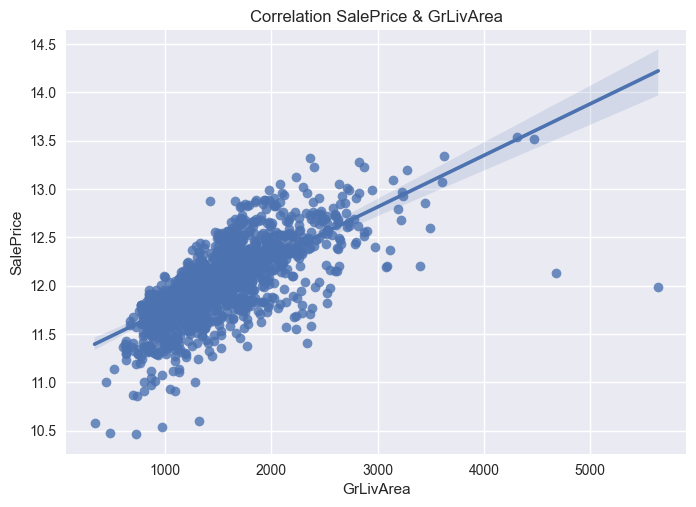

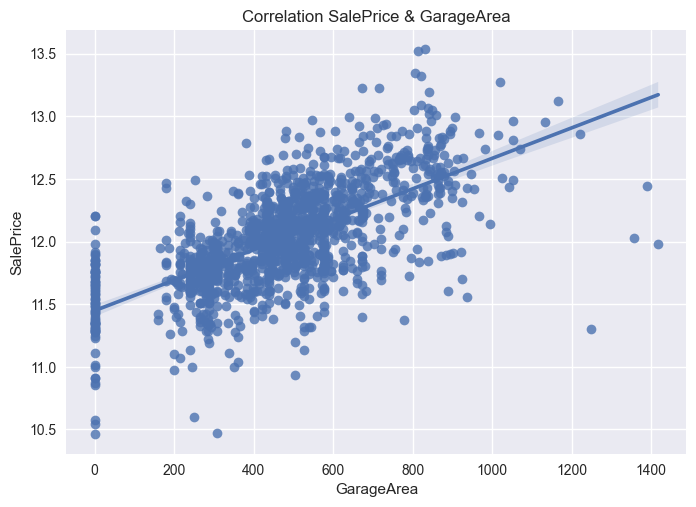

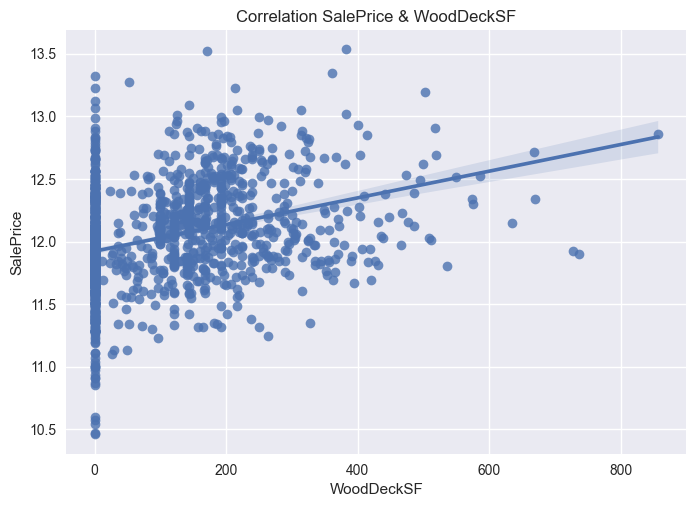

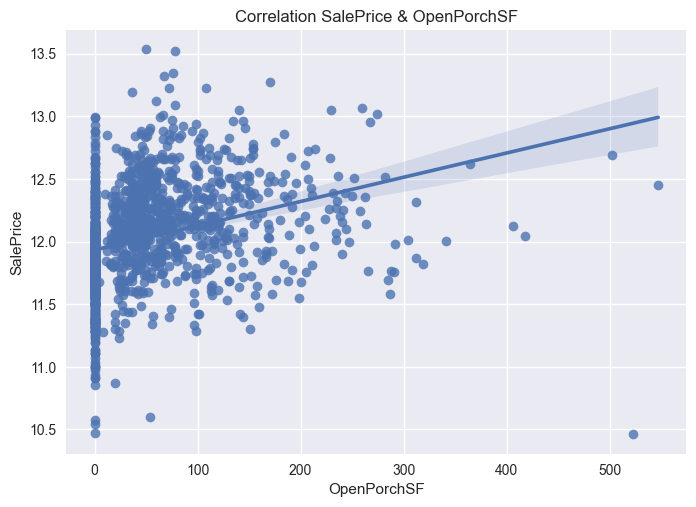

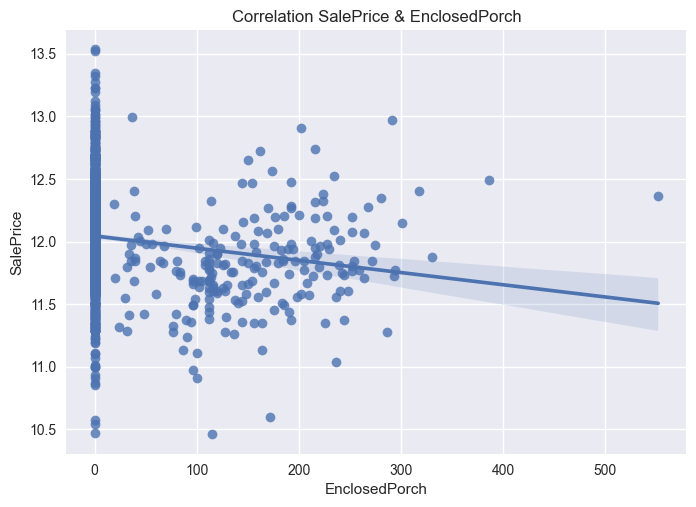

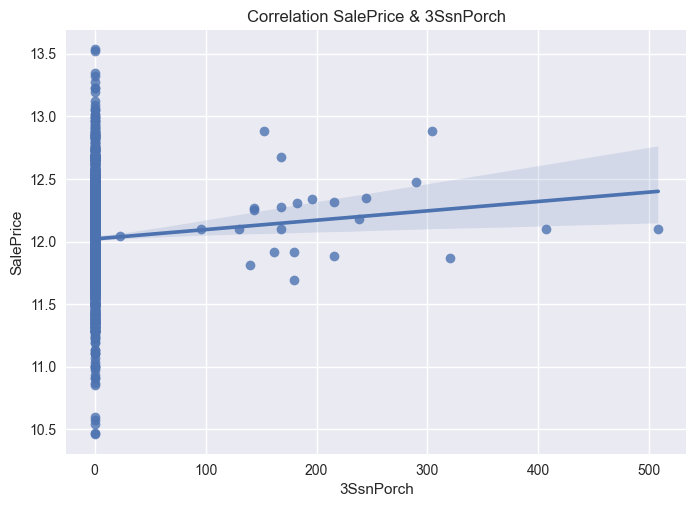

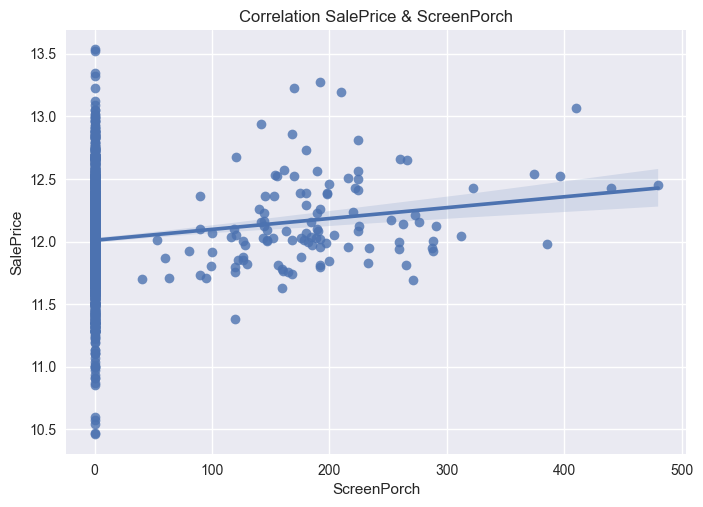

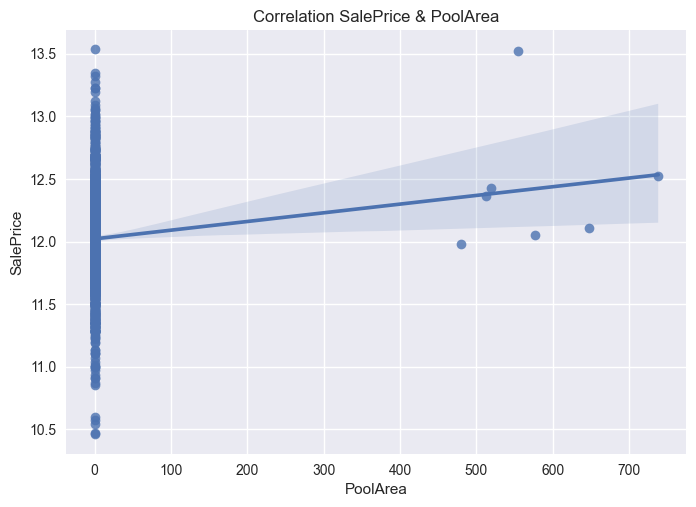

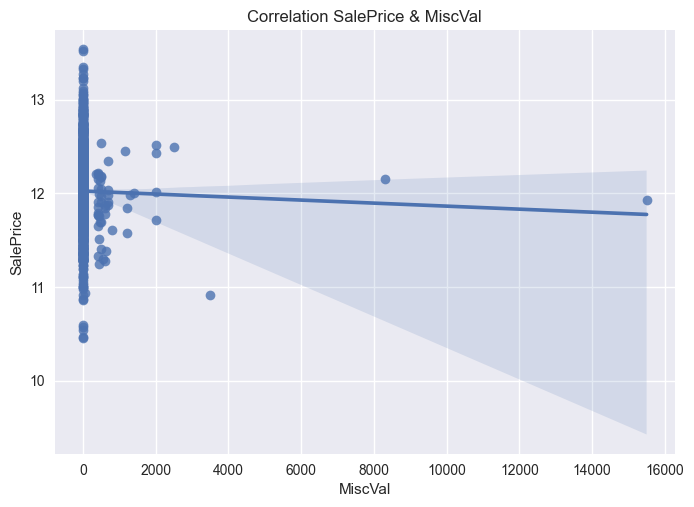

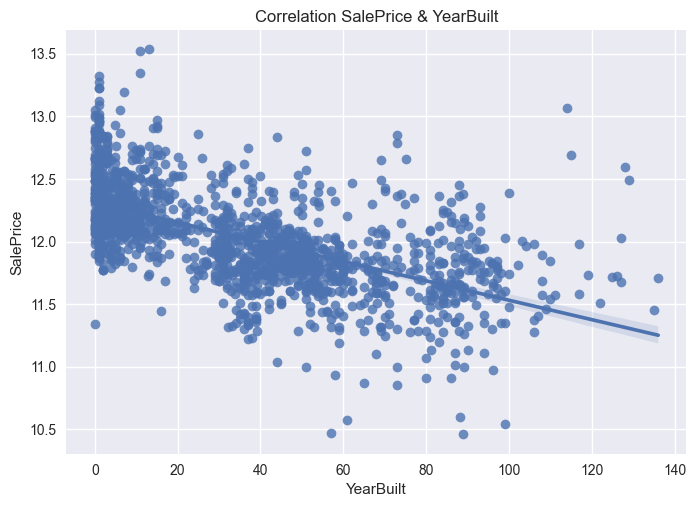

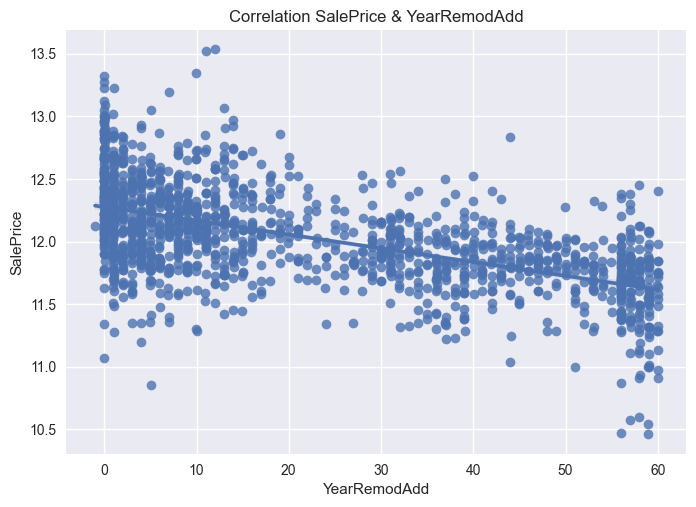

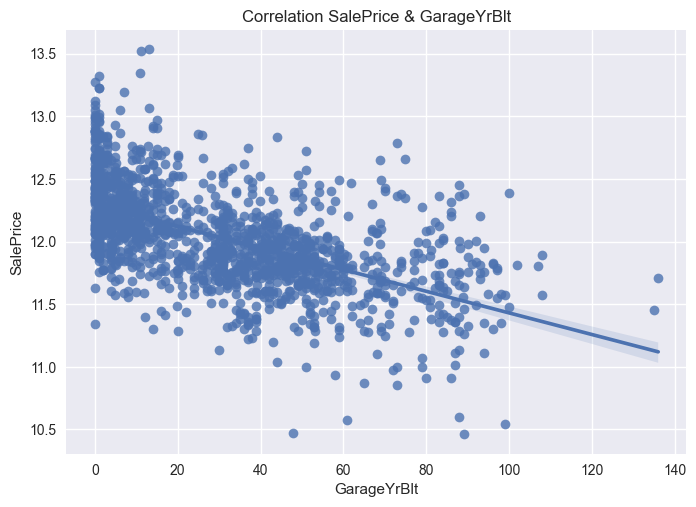

In [ ]:
scatter_plots(target, train_clean, numeric)

### Analyse des variables catégorielles

Pour les variables catégorielles, nous ne pouvons pas effectuer de corrélation pour des raisons évidentes. Nous devons donc effectuer une ANOVA (https://en.wikipedia.org/wiki/Analysis_of_variance) qui est la contrepartie dans le cas où nous voulons comprendre le lien entre une variable catégorielle et une variable numérique.

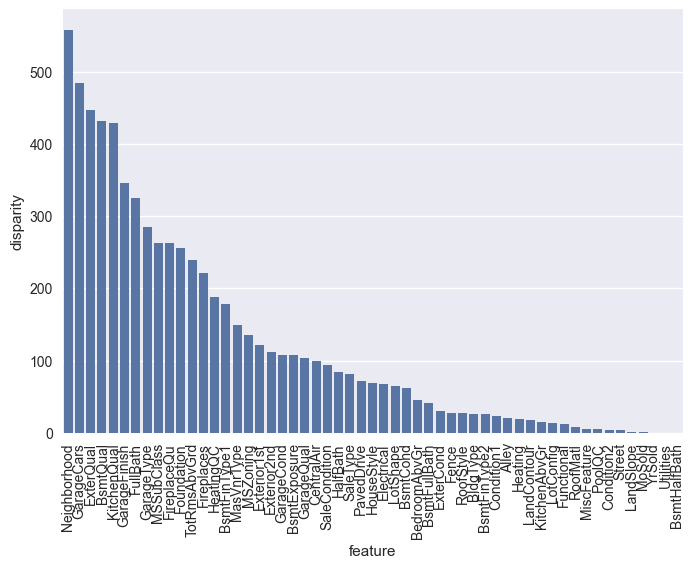

In [ ]:
def anova(y, X, features):
    
    anova = pd.DataFrame()
    anova['feature'] = features
    pvals = []
    
    for f in features:
        
        samples = []
        
        for cls in X[f].unique():
            
            s = y[X[f] == cls].values
            samples.append(s)
            
        pval = stats.f_oneway(*samples)[1]
        pvals.append(pval)
        
    anova['pval'] = pvals
    anova = anova.sort_values('pval')
    
    anova['disparity'] = np.log(1. / anova['pval'].values)

    sns.barplot(data = anova, x = 'feature', y = 'disparity')
    x = plt.xticks(rotation=90)
    
    return anova

anova = anova(target, train_clean, categorical)

In [ ]:
def box_plots(y, X, features) :
    
    for f in features :
        x = X[f]
    
        plt.title('Box plot ' + y.name + ' & ' + x.name)
        sns.boxplot(x = x, y = y)
        x = plt.xticks(rotation = 90)
        
        plt.show()

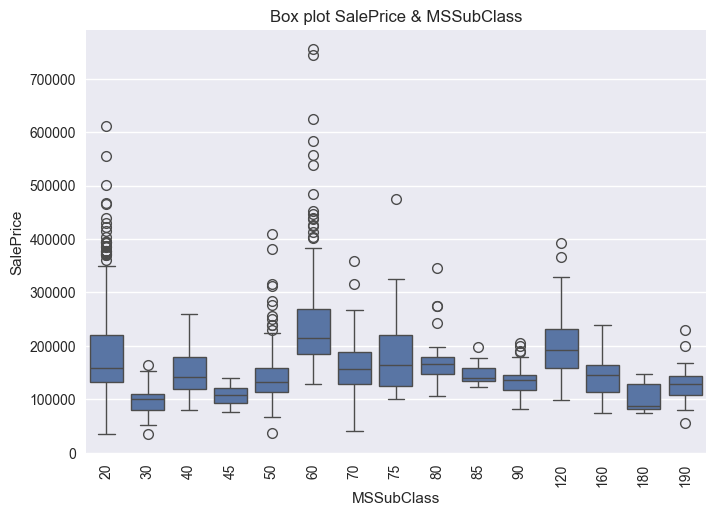

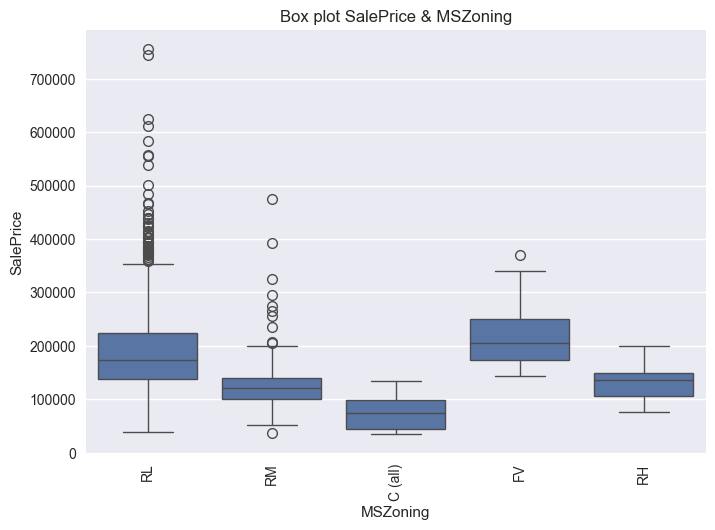

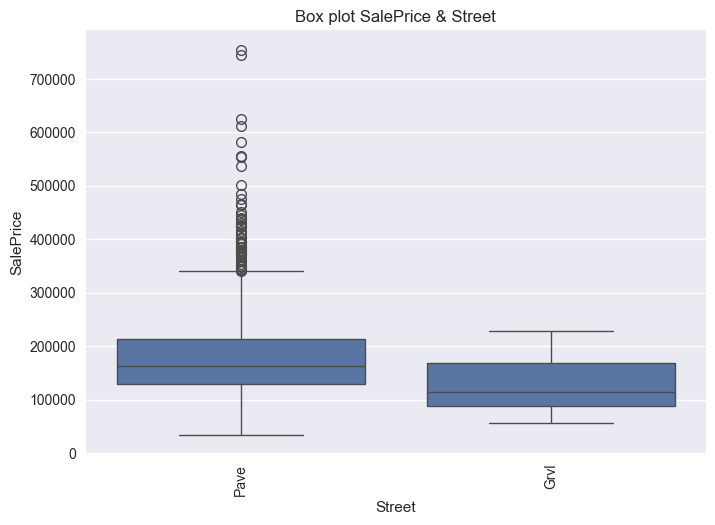

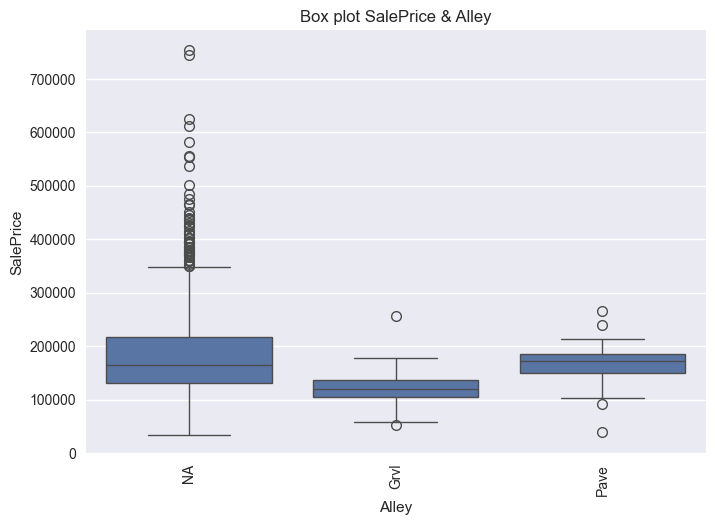

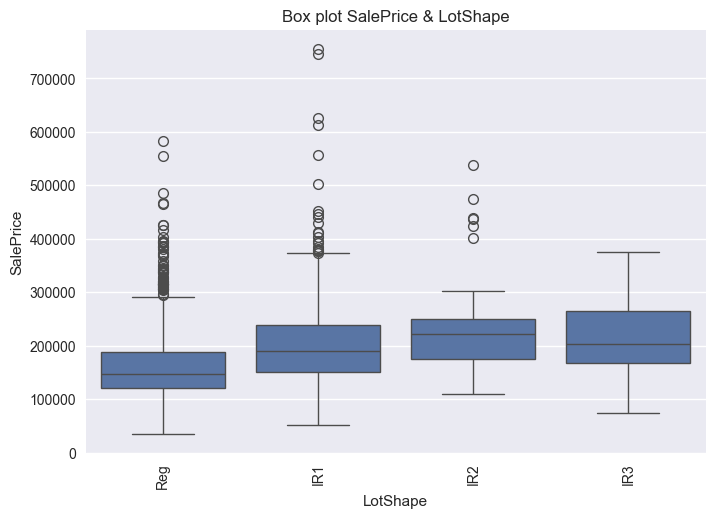

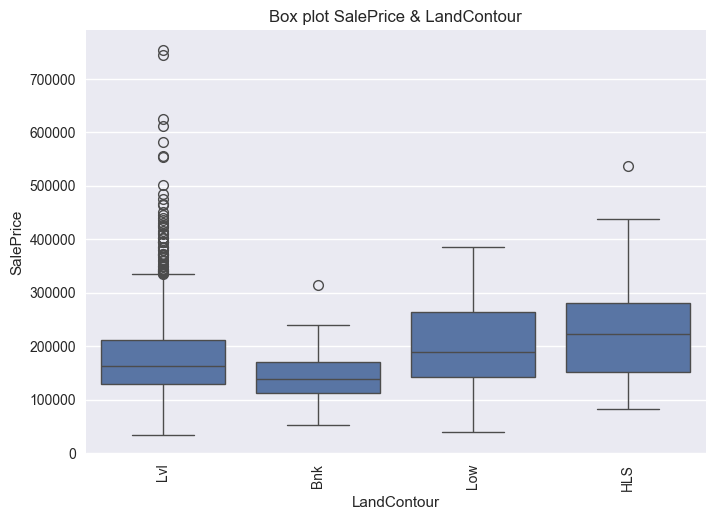

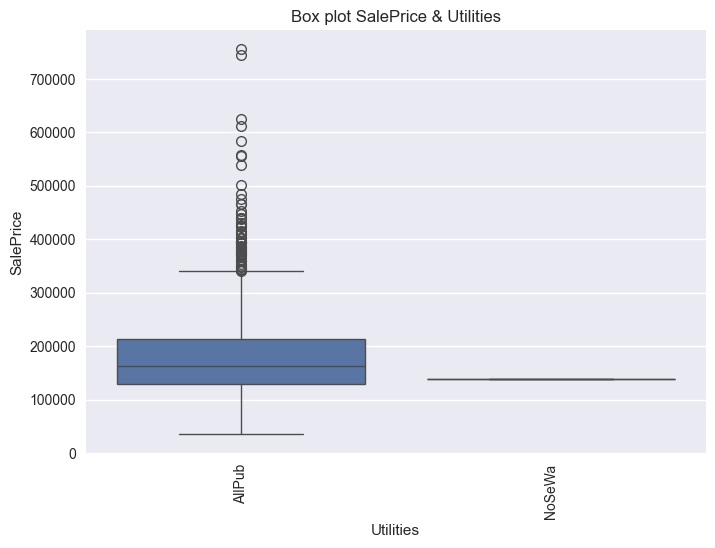

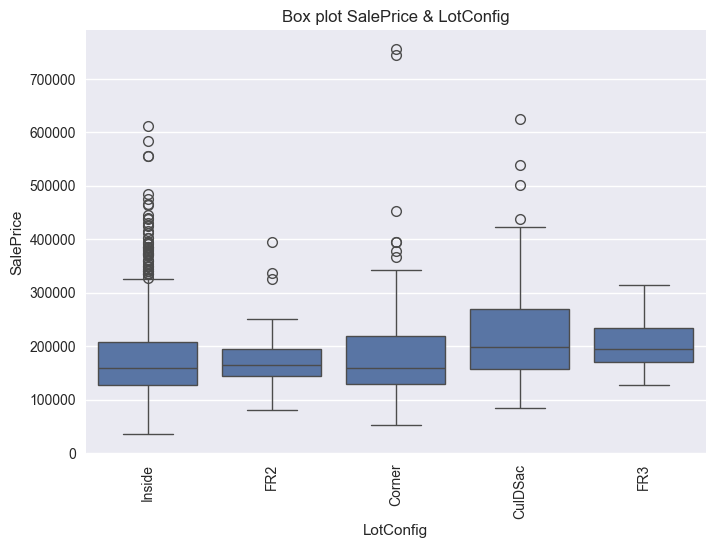

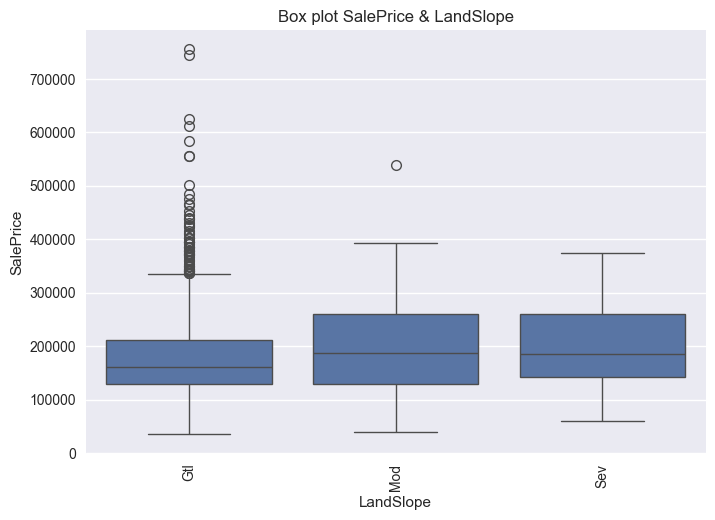

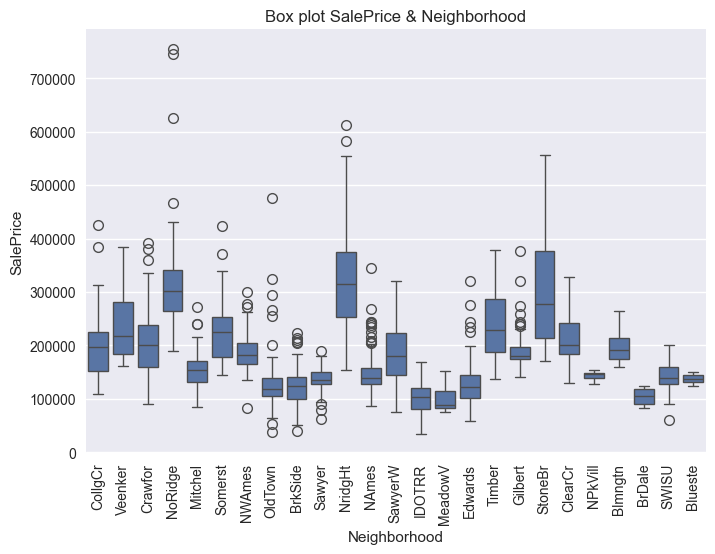

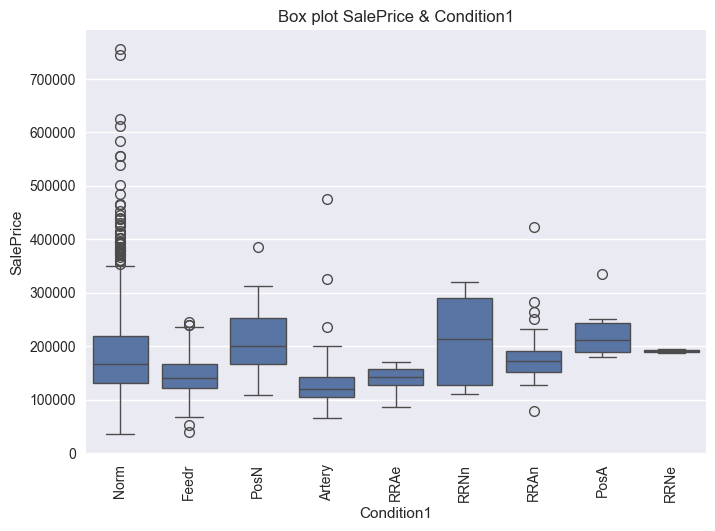

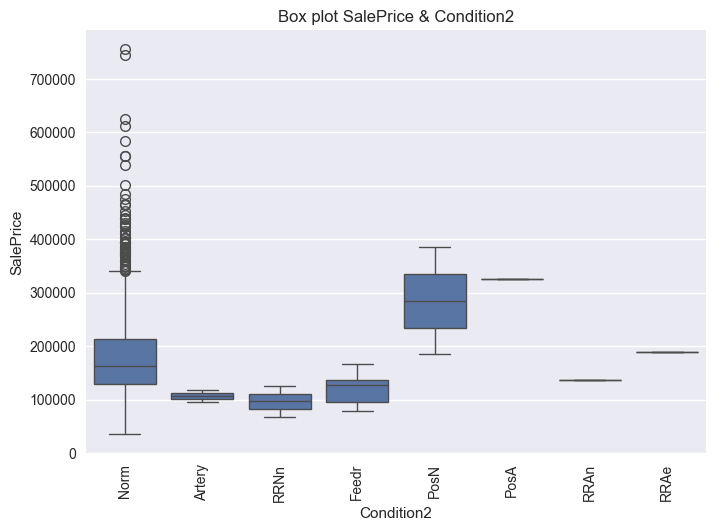

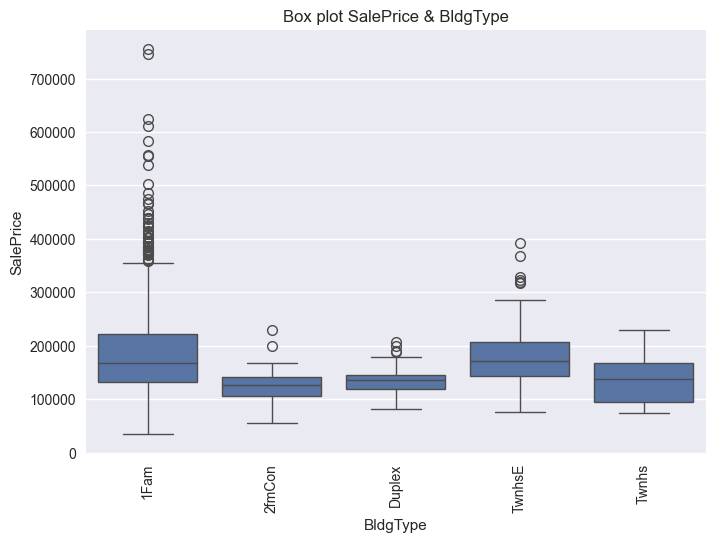

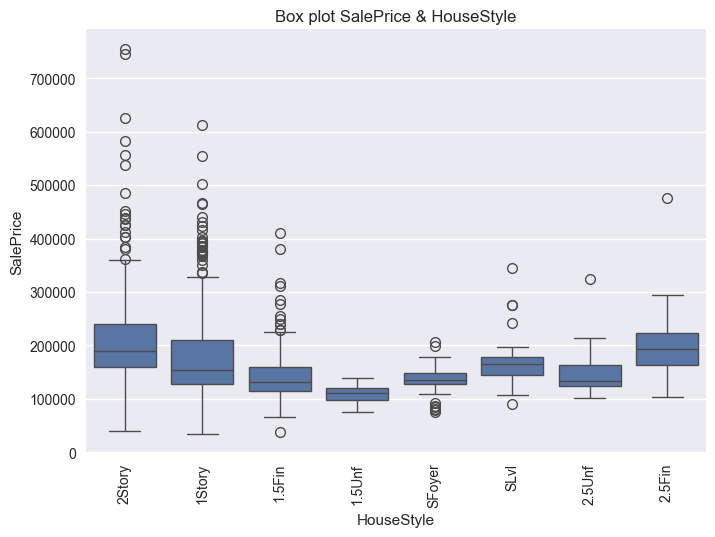

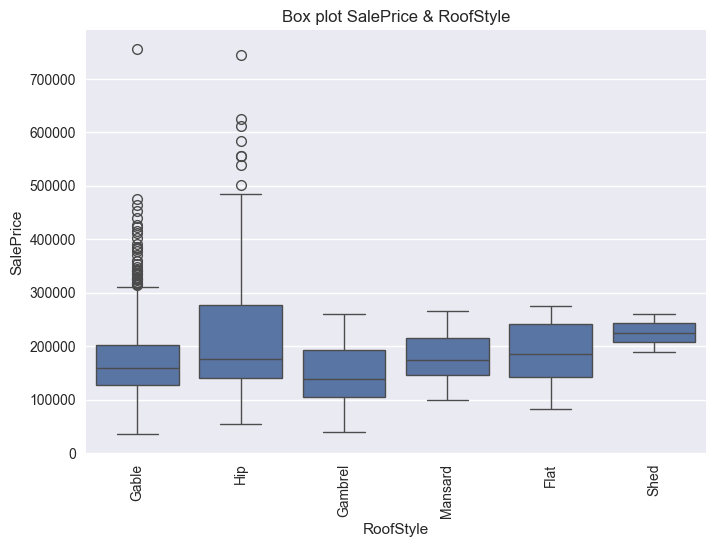

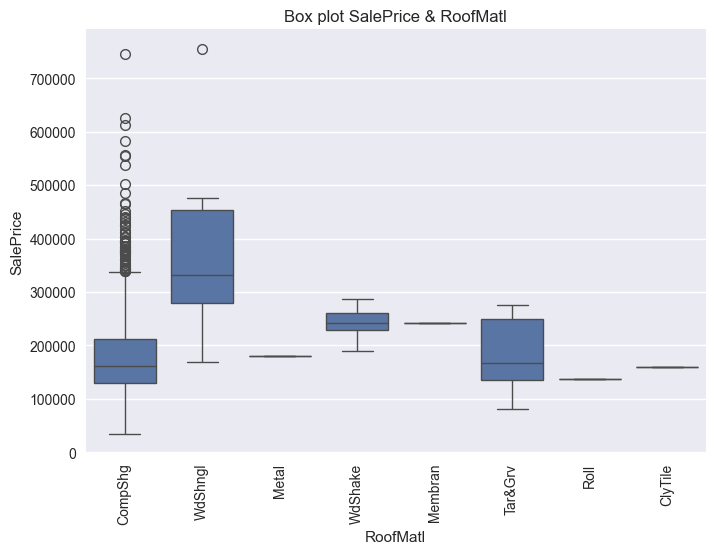

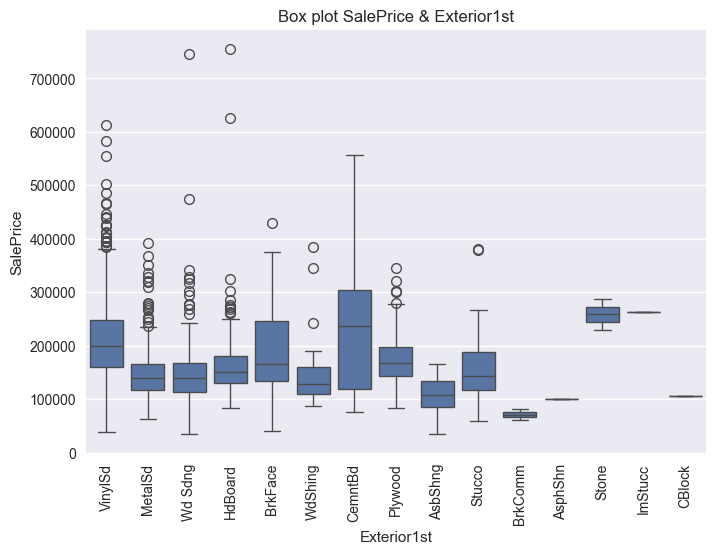

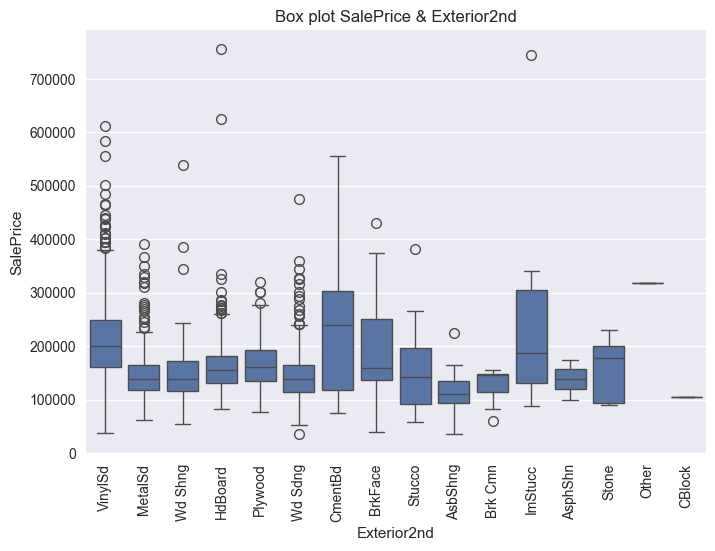

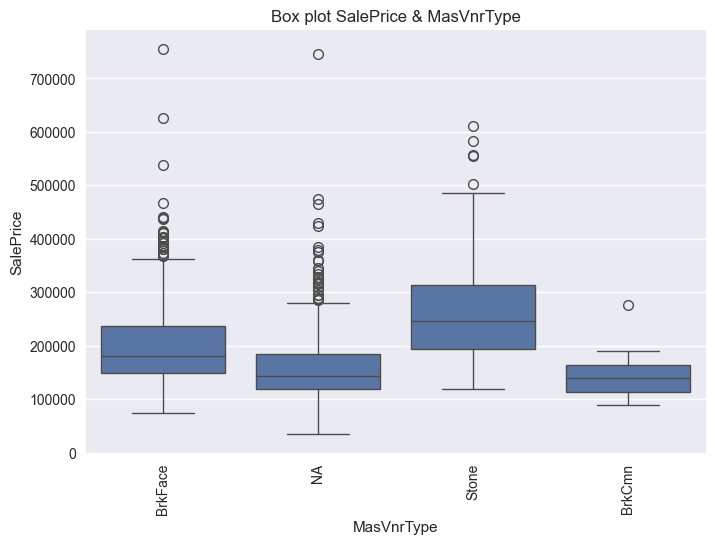

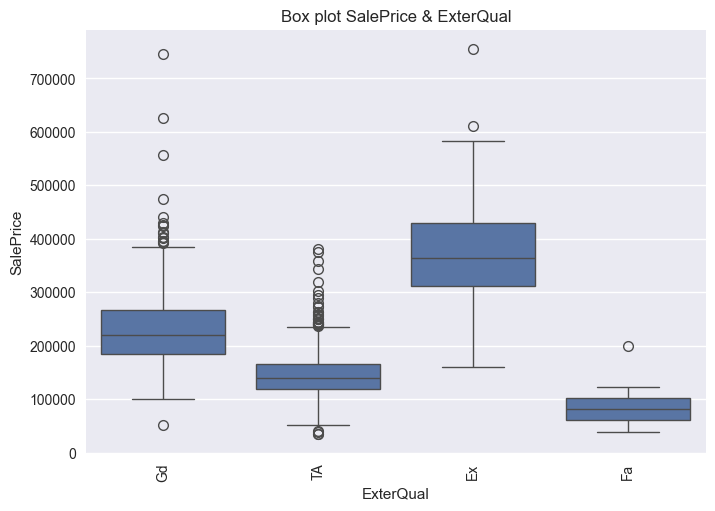

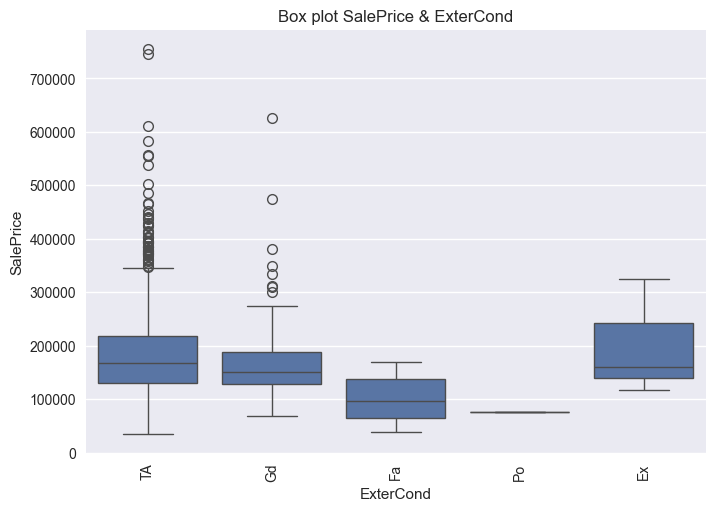

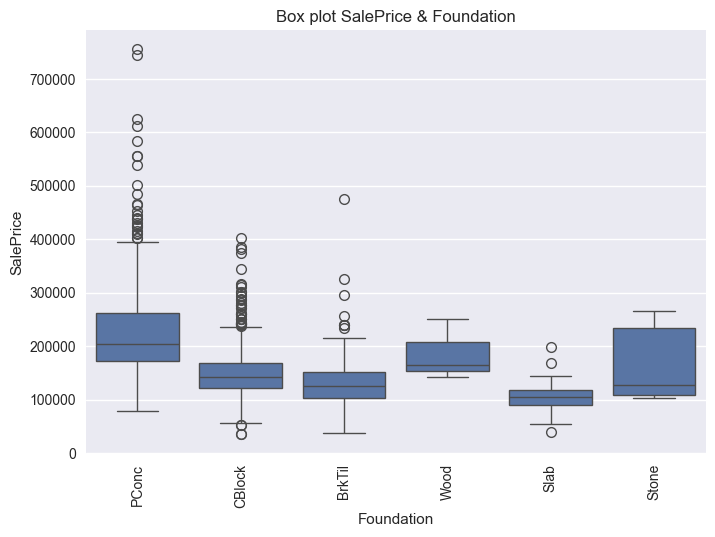

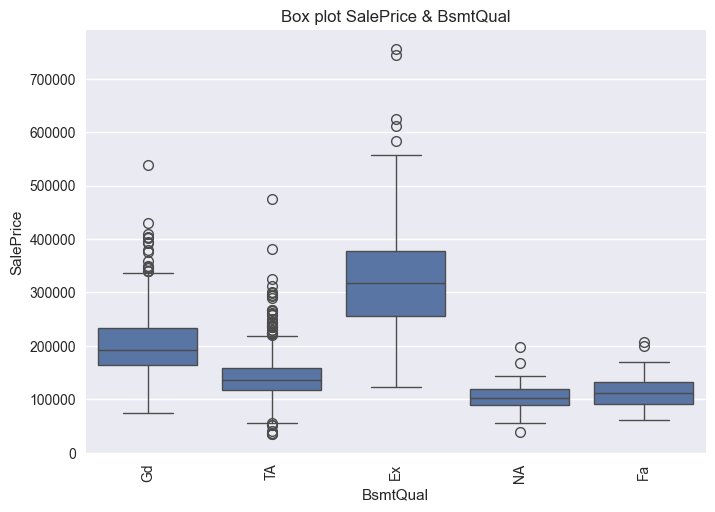

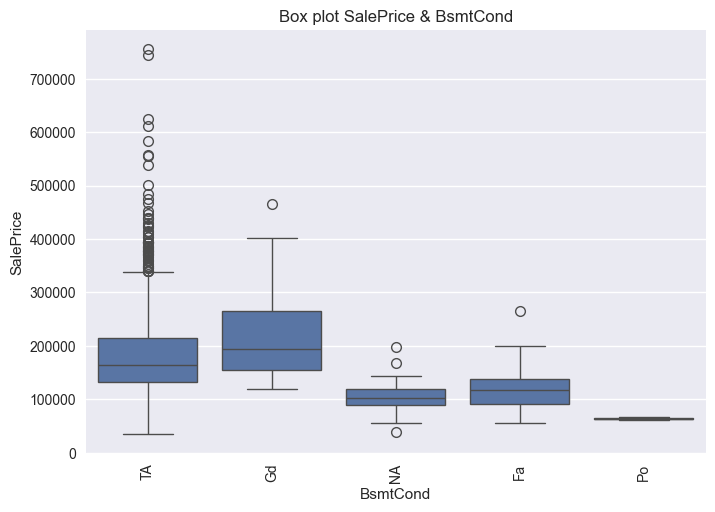

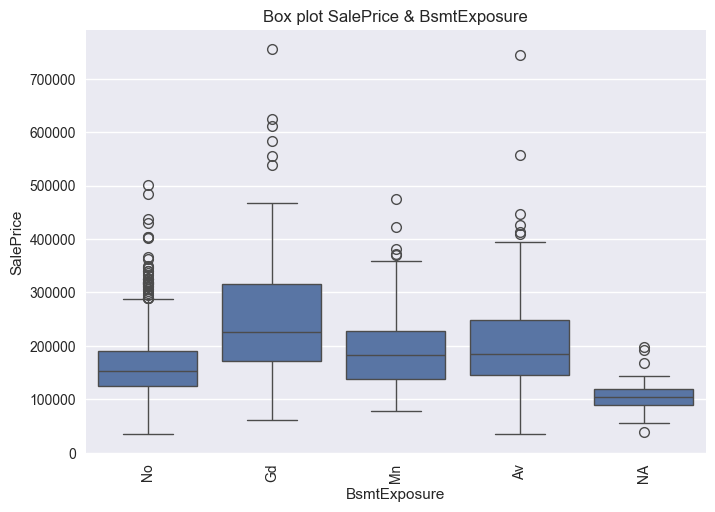

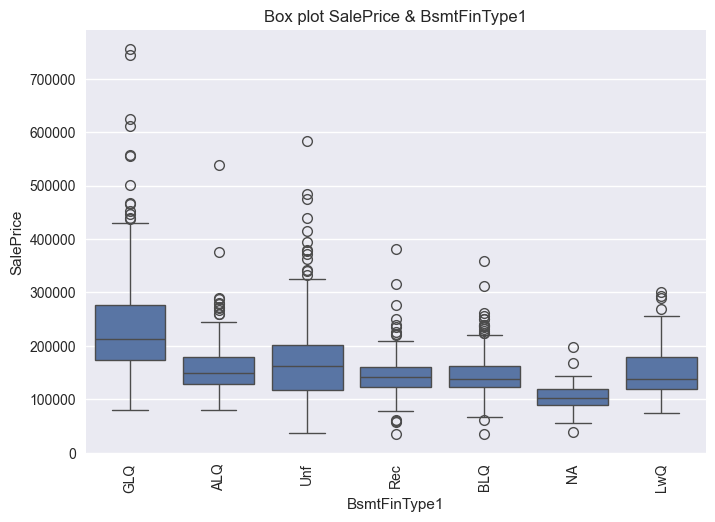

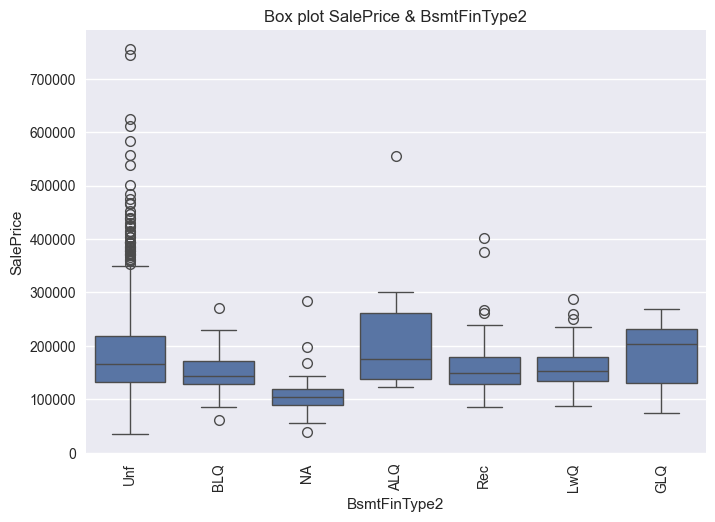

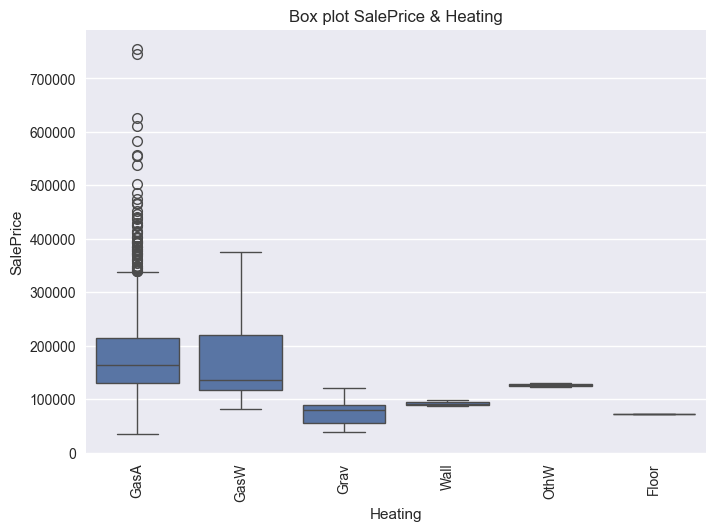

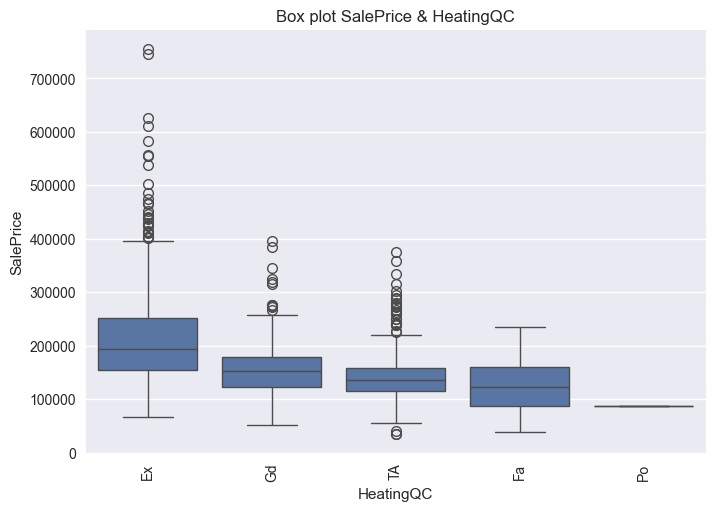

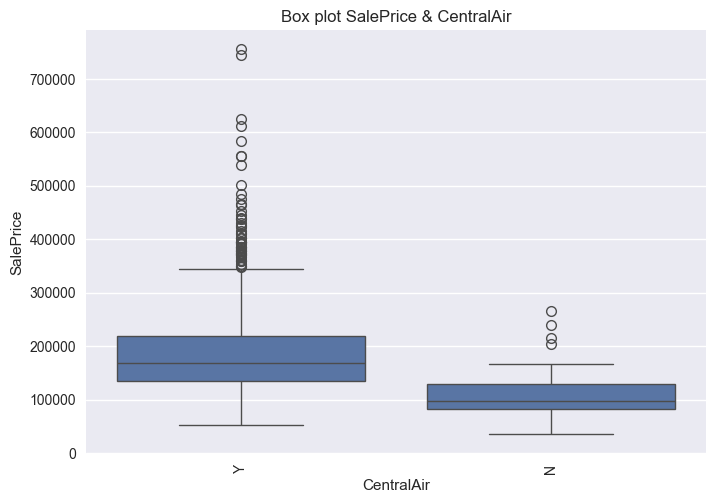

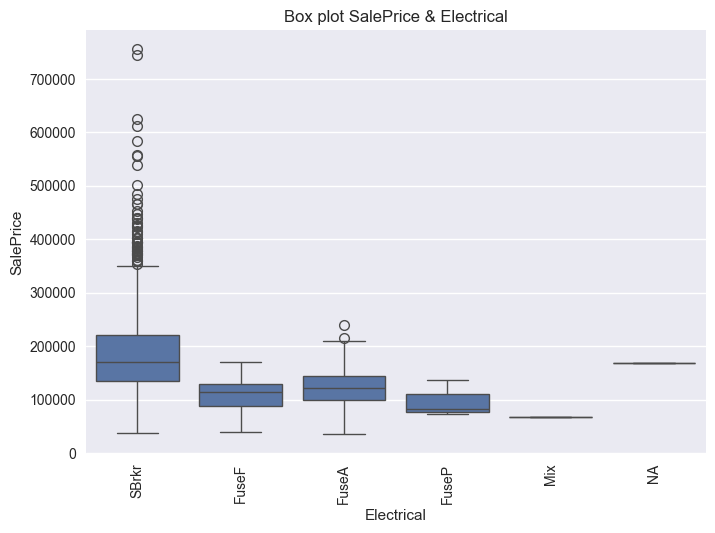

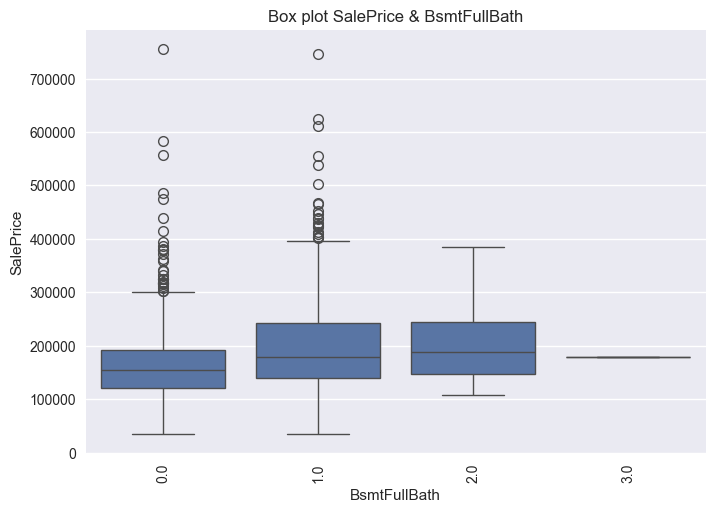

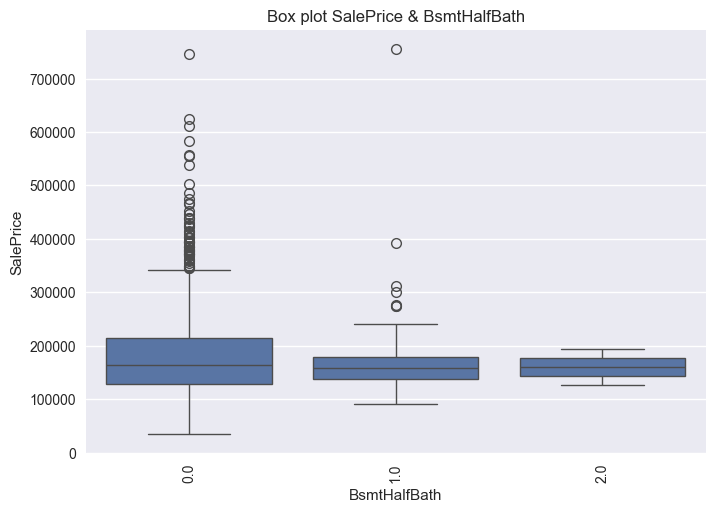

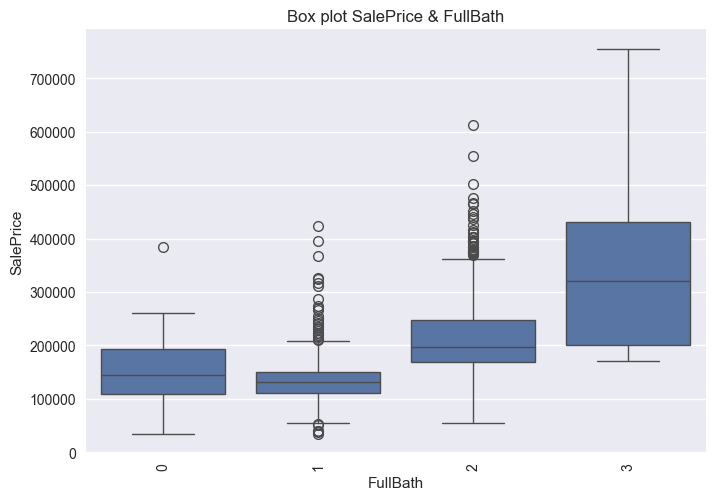

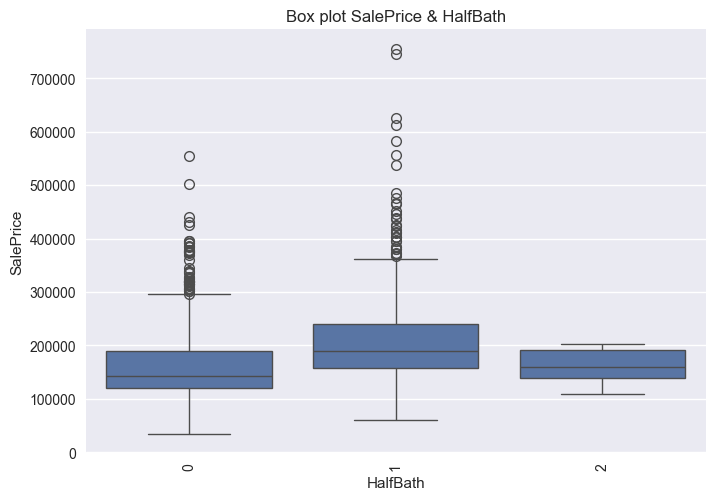

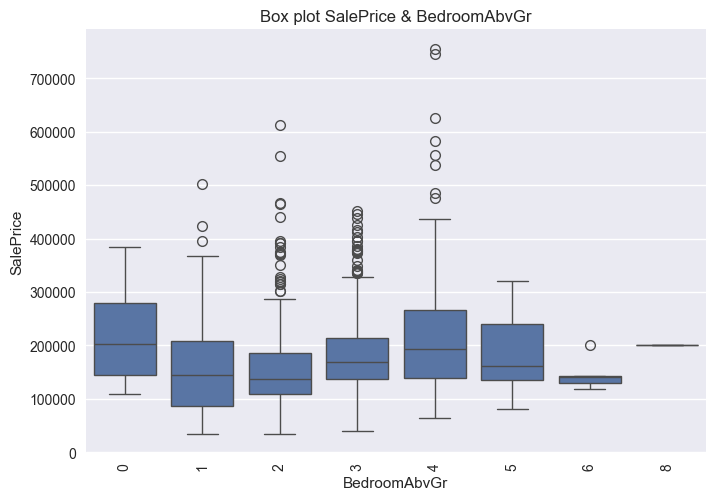

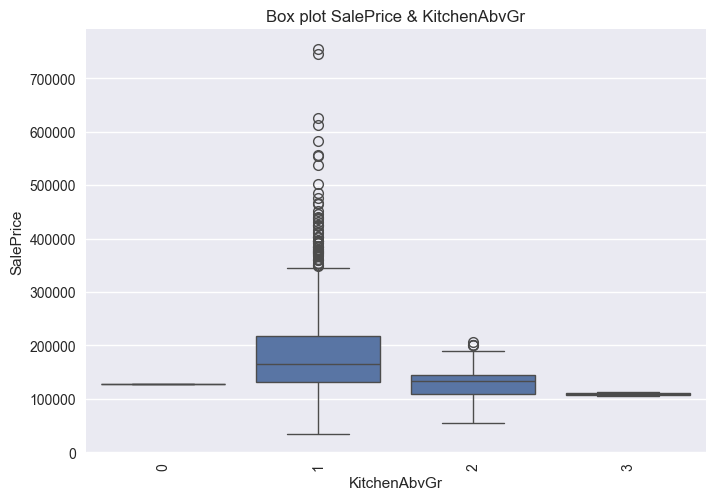

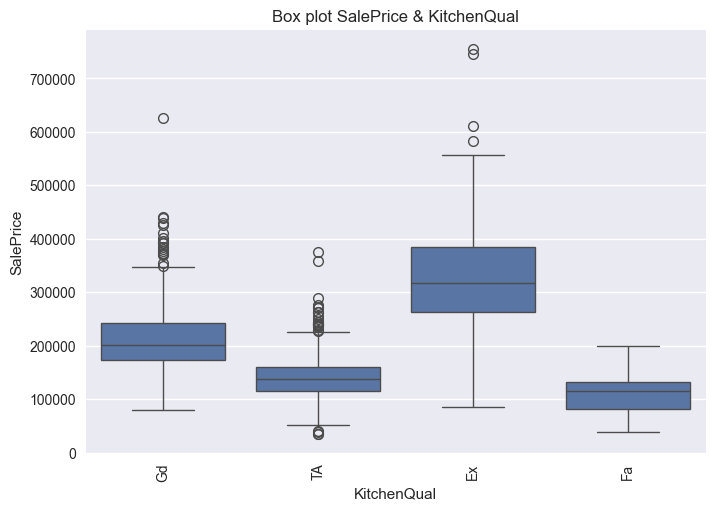

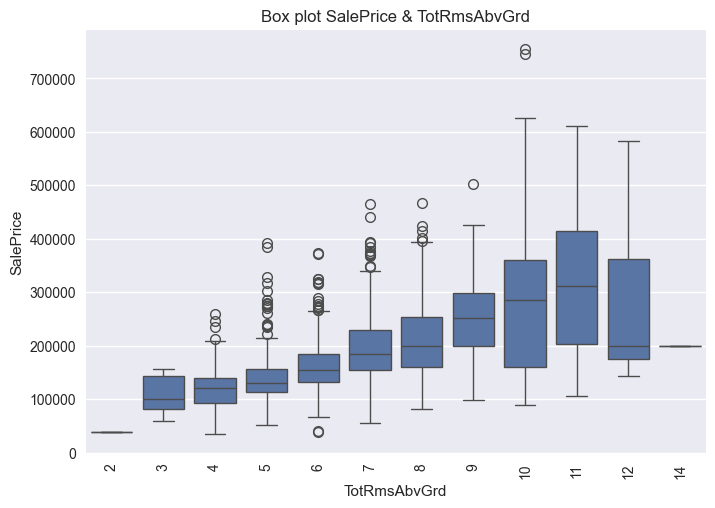

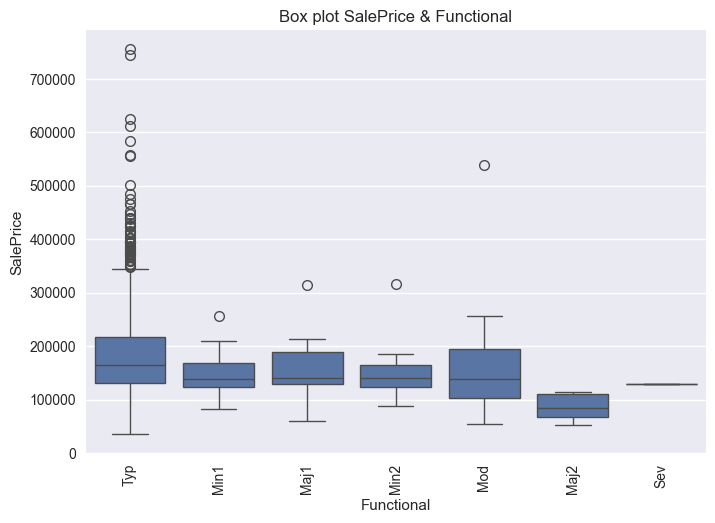

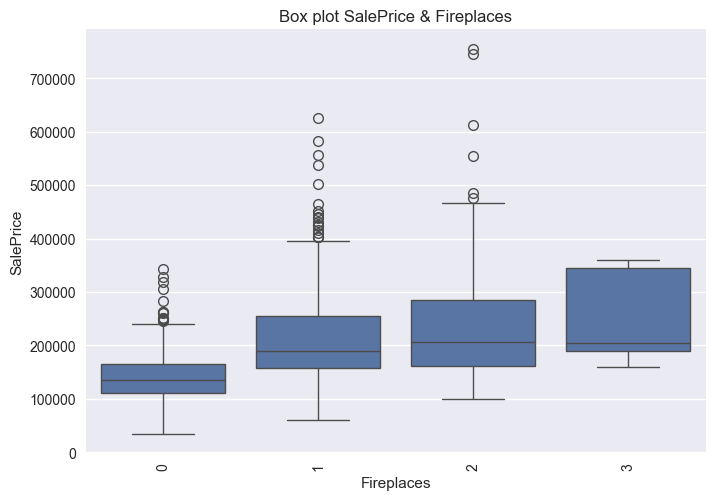

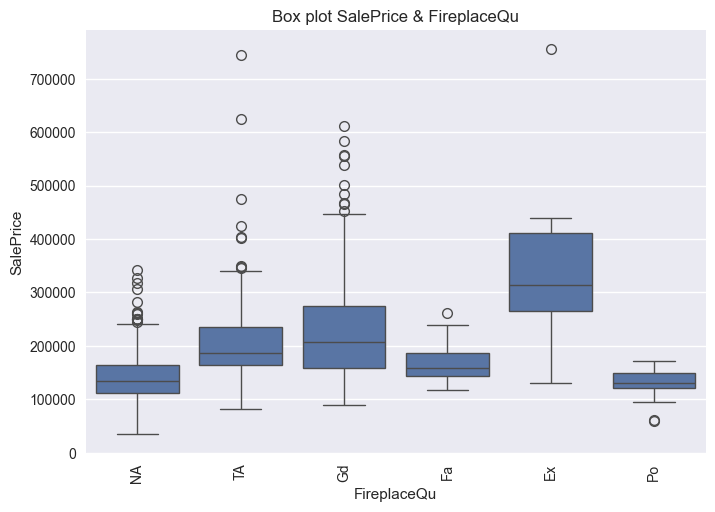

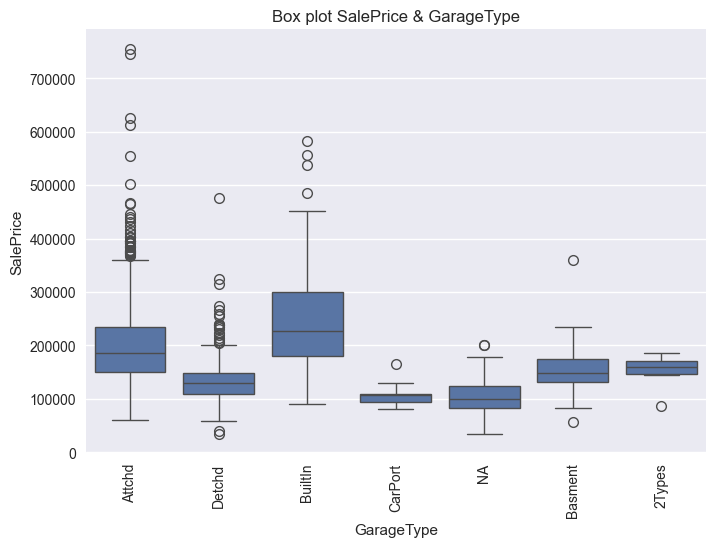

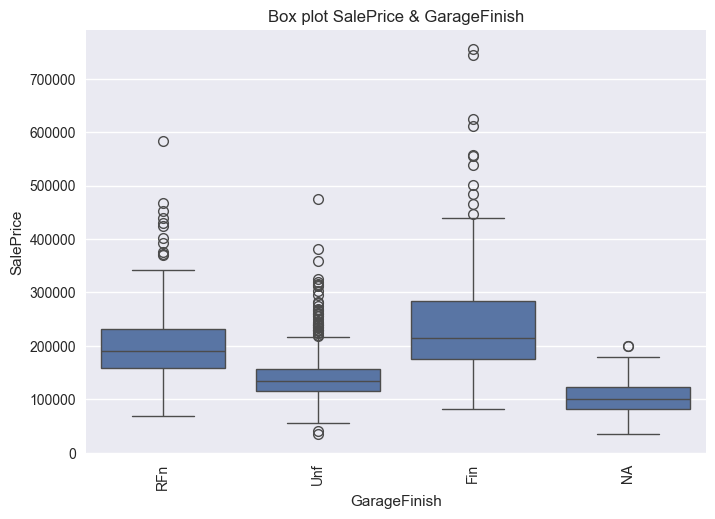

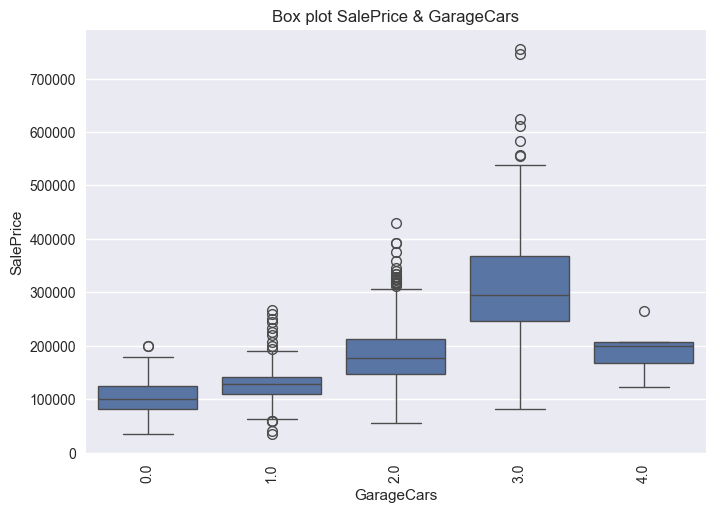

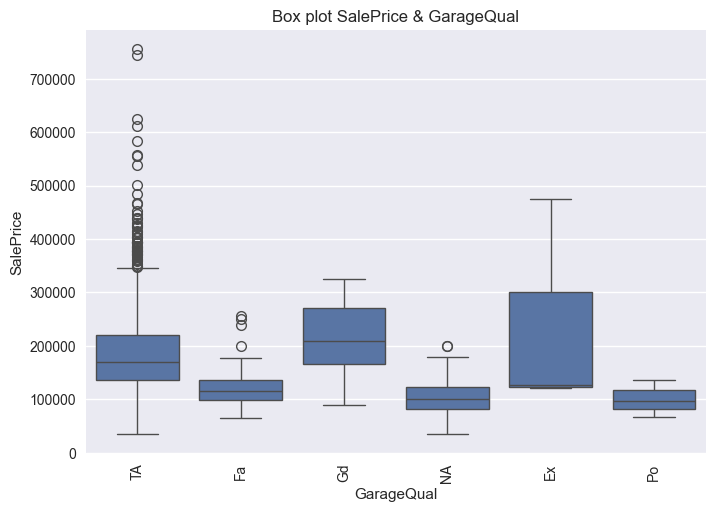

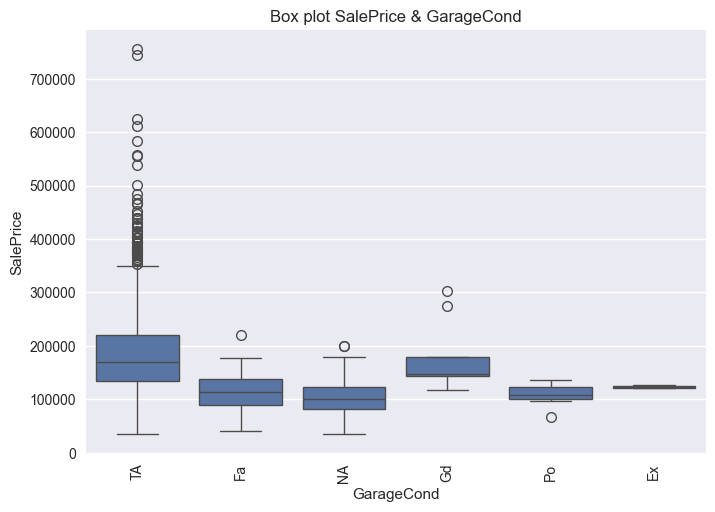

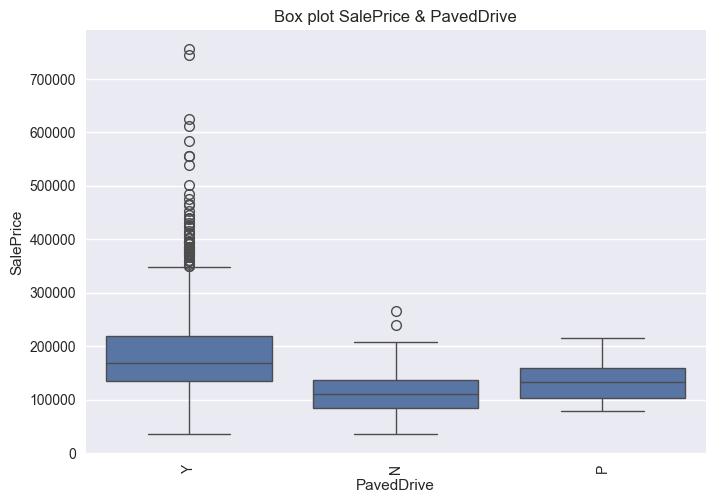

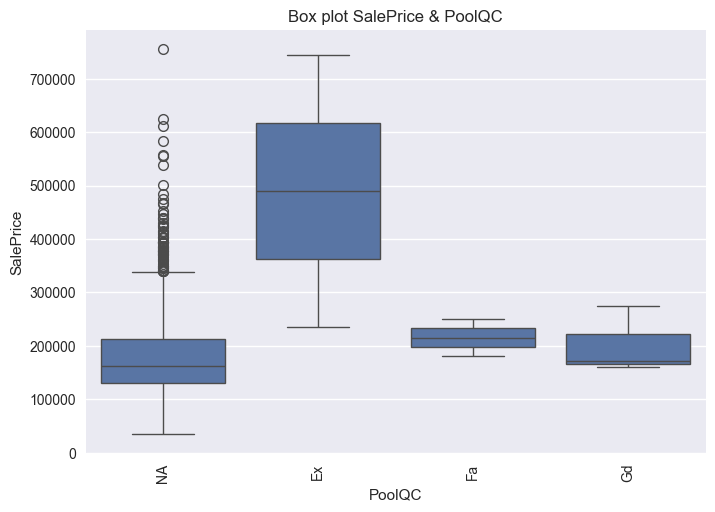

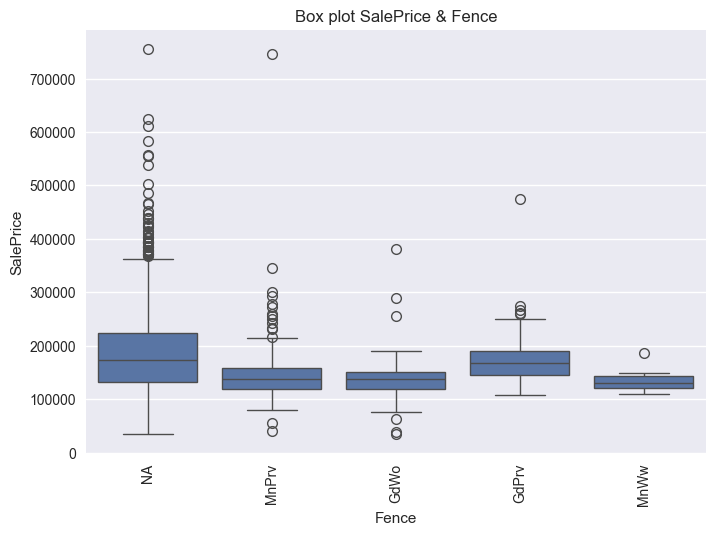

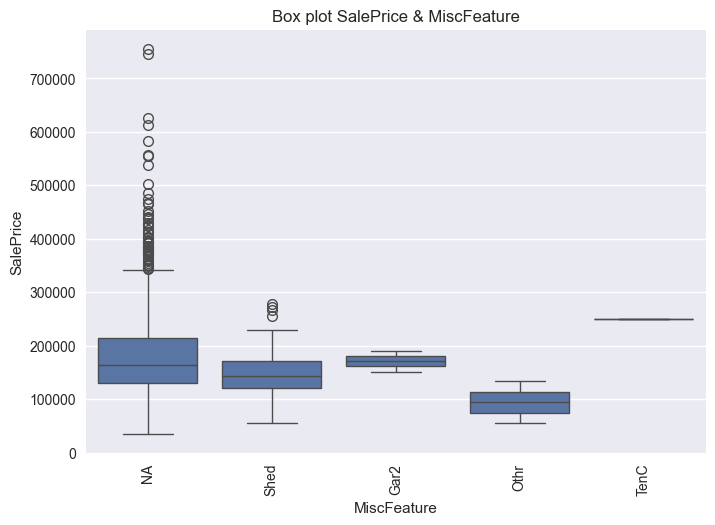

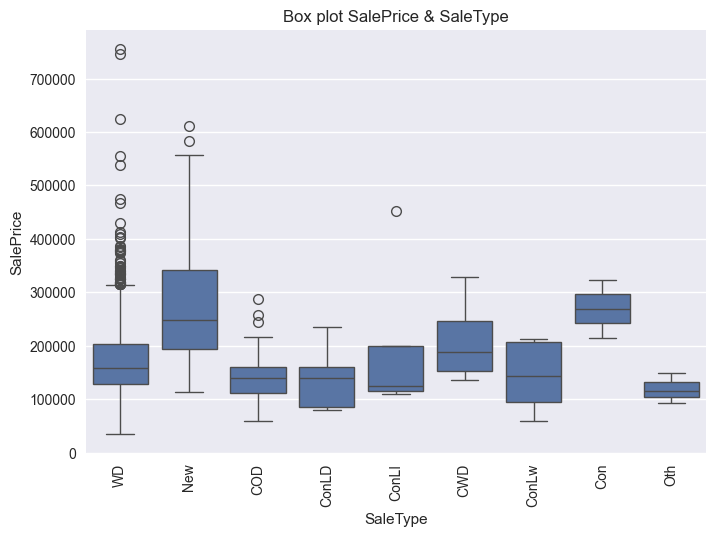

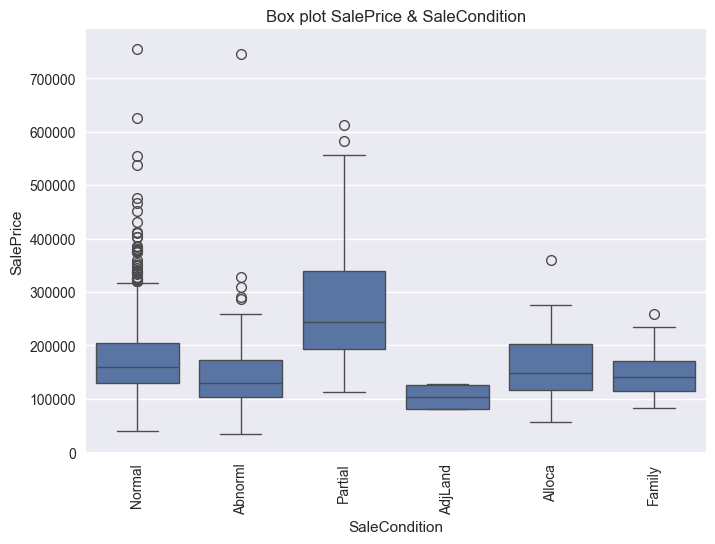

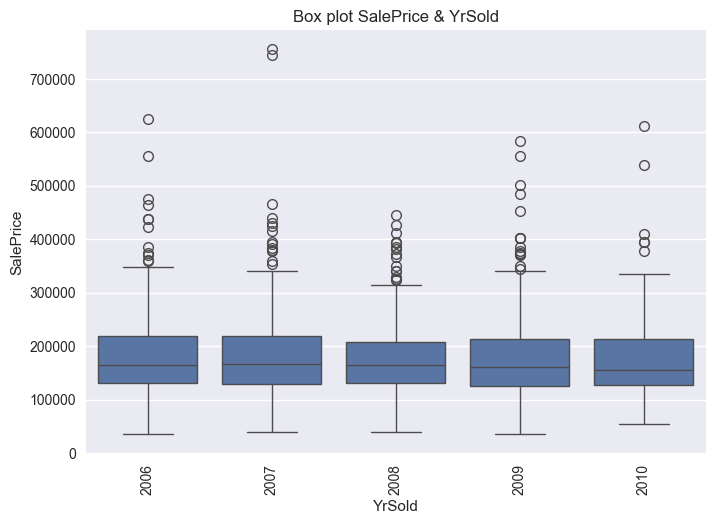

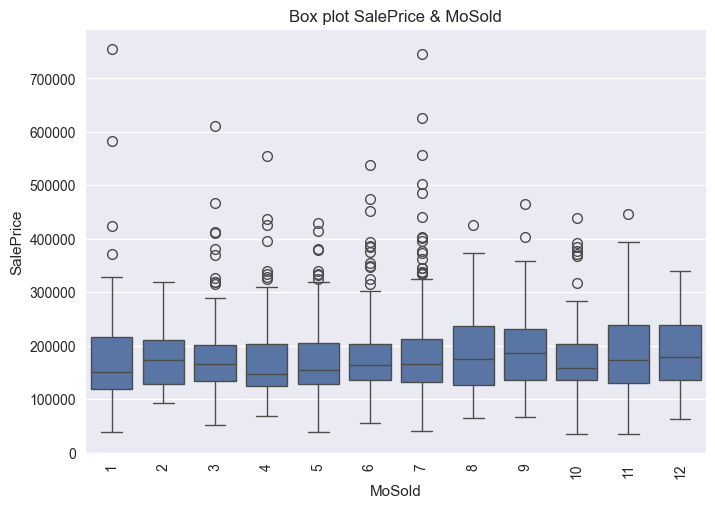

In [ ]:
box_plots(train_clean['SalePrice'], train_clean, categorical)

# Baseline Model Engineering

Créons maintenant notre modèle. Nous commencerons par un modèle de base simple, puis nous augmenterons la complexité.

## 2.1 Ingénierie des données de base

Afin d'effectuer une analyse de régression, nous devons préparer un peu plus notre ensemble de données. En particulier, nous allons transformer les variables catégorielles en variables numériques.

Une astuce intéressante dans notre scénario de régression consiste à remplacer la catégorie par la **moyenne** de notre variable cible pour cette catégorie. Cette transformation crée alors une corrélation naturelle entre notre nouvelle variable et notre variable cible. Une autre approche (factice) consisterait à utiliser simplement pd.getDummies(), mais ce n'est pas si efficace et trompeur à mon avis.



In [ ]:
def encode_with_mean(data, target, features):
    
    data_preprocess = data.copy()
    
    for f in features: 
        
        # create a temporary dataframe for our workload
        frame = pd.DataFrame()
        frame[f] = data[f].copy()
        frame[target.name] = target.copy()
        
        # create the mapping table
        mapping = pd.DataFrame()
        mapping['val'] = data[f].unique()
        mapping.index = mapping.val
        
        # compute the mean of our target variable for each category
        mapping['mean'] = frame[[f, target.name]].groupby(f).mean()[target.name]
        
        # if a category has NA, we shall simply put the mean value
        mapping['mean'] = mapping['mean'].fillna(target.mean())

        # we replace the feature with the means in the mapping table
        data_preprocess[f] = pd.merge(data_preprocess, mapping, left_on = f, right_index = True)['mean'].copy()
        
    return data_preprocess

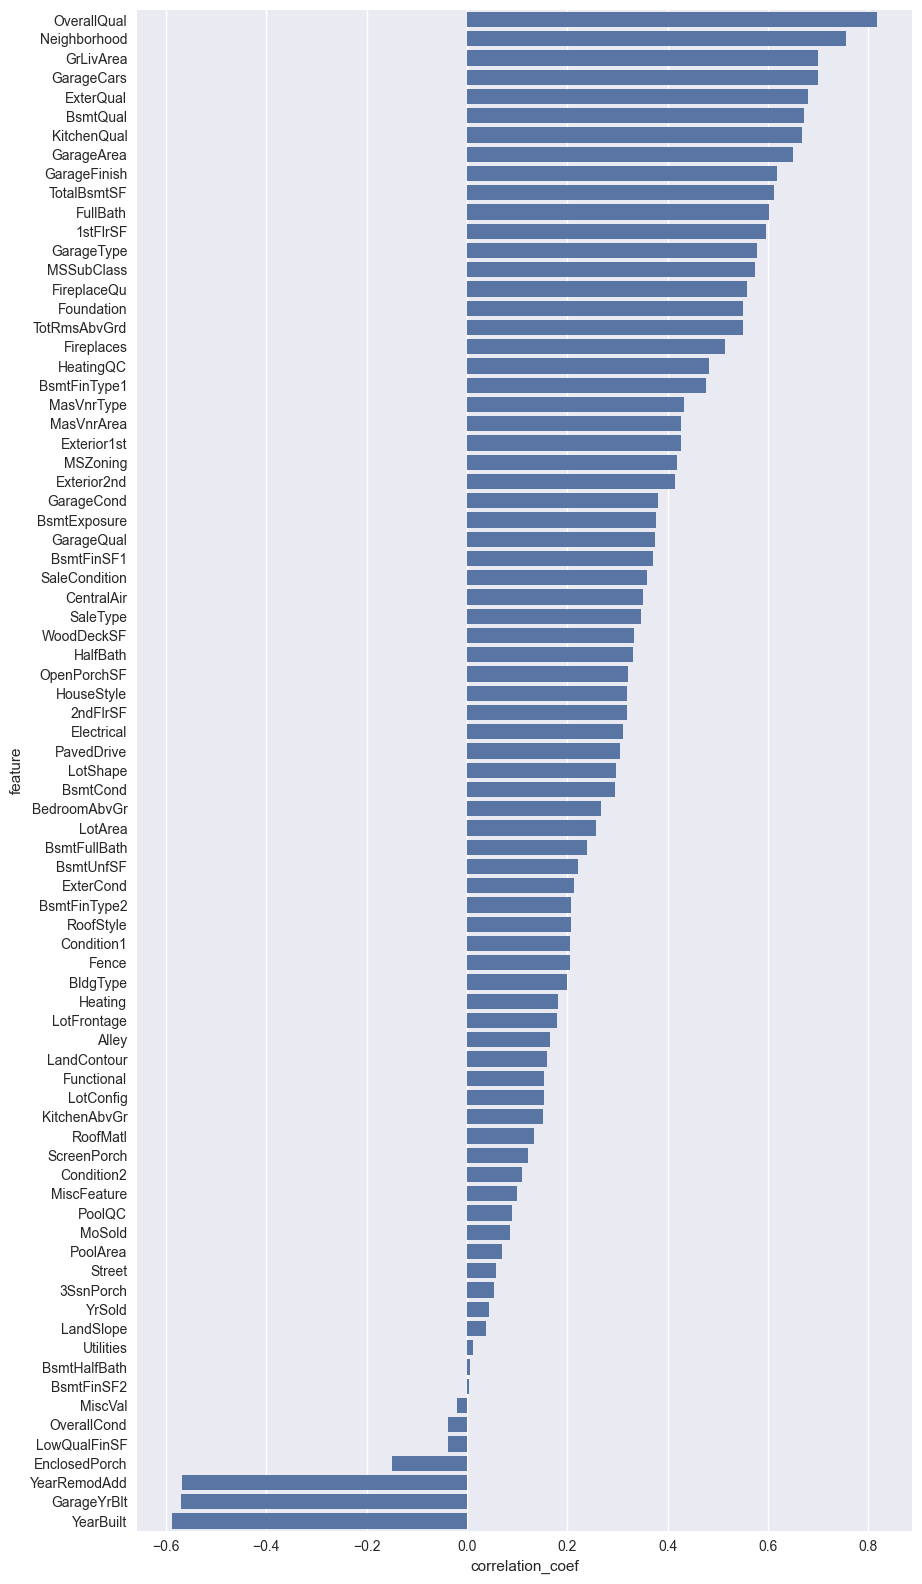

In [36]:
data_preprocess = encode_with_mean(data_clean, target, categorical)

# Split of the clean dataset into train & validation
train_preprocess = data_preprocess[data_preprocess.index.isin(train_raw.index)]
validation_preprocess = data_preprocess[data_preprocess.index.isin(validation_raw.index)]

cor = correlation(target, train_preprocess, numeric + categorical)

Nous constatons que de nombreuses caractéristiques sont en corrélation avec le **logarithme du prix de vente**, ce qui est bon pour notre cas d'utilisation. Jetons un coup d'œil à la corrélation interne entre les variables. Nous limitons notre visualisation aux caractéristiques qui ont une corrélation modérée ou supérieure (c'est-à-dire un coefficient de corrélation supérieur à 0,5 en valeur absolue).



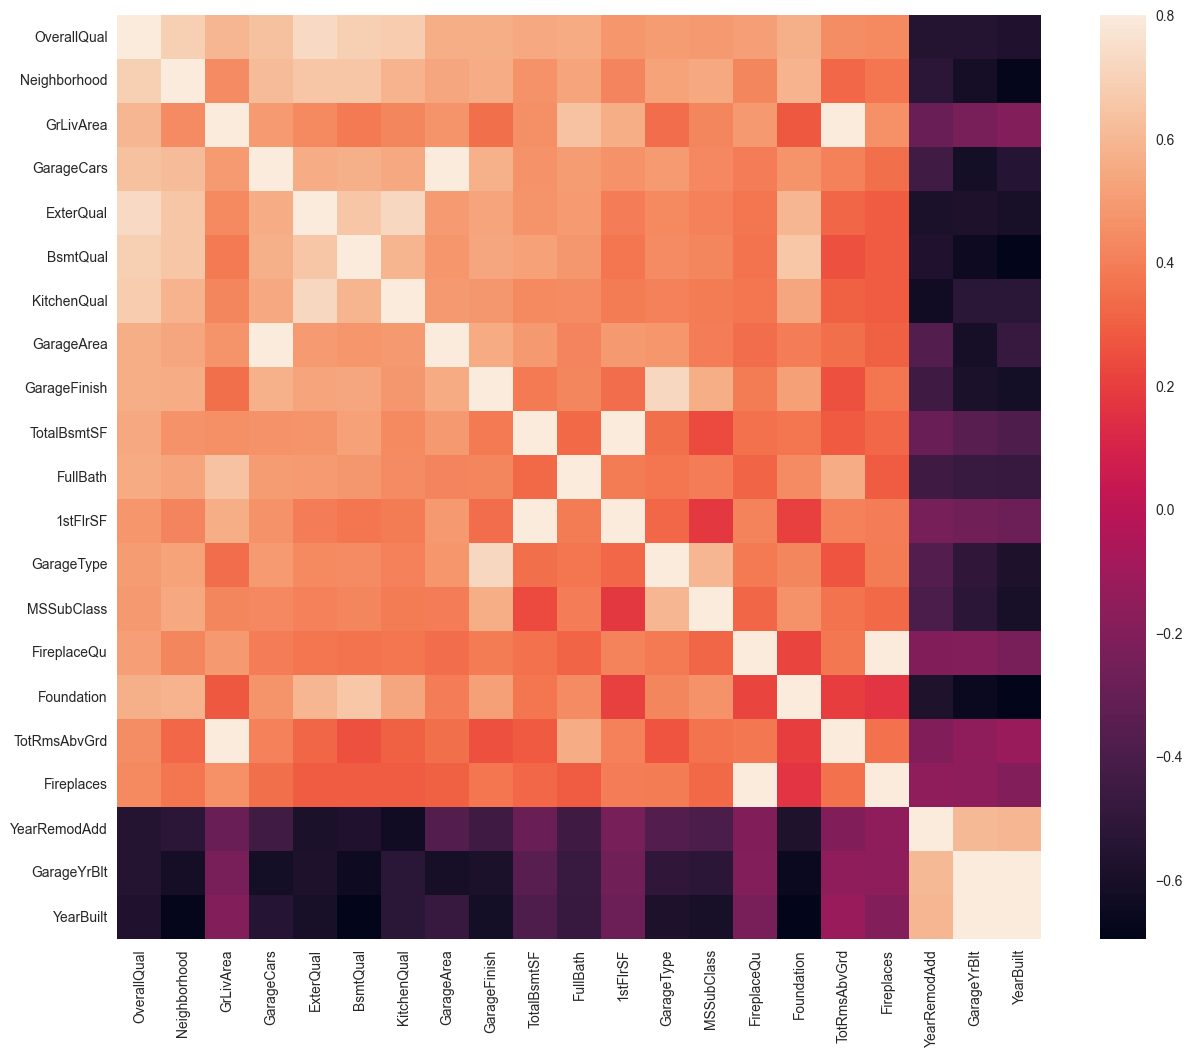

In [37]:
cols = cor[abs(cor['correlation_coef']) > 0.5]['feature'].tolist()
correlation_matrix = train_preprocess[cols].corr()
f, ax = plt.subplots(figsize=(15, 12))
sns.heatmap(correlation_matrix, vmax=.8, square=True)
plt.show()

Il existe de nombreuses corrélations internes. Nous devrons donc sélectionner soigneusement les variables afin d'éviter la multicolinéarité.

## 2.2 Baseline Model - Linear Regression

Nous commençons par le modèle le plus basique, à savoir la régression linéaire. D'après notre analyse et notre compréhension du marché du logement, il est intéressant de considérer les variables suivantes :

- OverallQual
- Neighborhood
- GrLivArea
- TotalBsmtSF
- YearBuilt

C'est tout à fait logique, car ce sont les principales variables que l'on recherche pour une maison, à savoir la qualité générale du bien, le quartier, la surface habitable et l'année de construction de la maison. Le sous-sol est particulièrement important à Ames, car il s'agit d'une région où le risque de tornade est élevé.

In [38]:
base = ['OverallQual', 'Neighborhood', 'GrLivArea', 'TotalBsmtSF', 'YearBuilt']

X = train_preprocess[base]
X_val = validation_preprocess[base]

y = target.copy()

To fit the linear regression, we use the library StatsModels which comes with very handy functions for model understanding.

In [39]:
import statsmodels.api as sm

model = sm.OLS(y, sm.add_constant(X))
res = model.fit()

print(res.summary())

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.825
Model:                            OLS   Adj. R-squared:                  0.824
Method:                 Least Squares   F-statistic:                     1367.
Date:                Wed, 30 Apr 2025   Prob (F-statistic):               0.00
Time:                        13:36:35   Log-Likelihood:                 539.40
No. Observations:                1460   AIC:                            -1067.
Df Residuals:                    1454   BIC:                            -1035.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            6.8392      0.271     25.244   

### Hypothèses de régression linéaire

Si nous voulons utiliser une régression linéaire, nous devons vérifier certaines hypothèses, à savoir :

- Linéarité du lien entre les variables indépendantes et la variable dépendante.
- Les résidus sont normalement distribués autour de 0
- Homoscédasticité
- Les résidus sont exempts de structure
- Les résidus sont exempts de valeurs aberrantes

Voici un code que j'ai trouvé sur https://robert-alvarez.github.io/2018-06-04-diagnostic_plots/ et qui fait cela très bien.
*** Traduit avec www.DeepL.com/Translator (version gratuite) ***



In [40]:
from statsmodels.graphics.gofplots import ProbPlot
plt.rc('font', size=14)
plt.rc('figure', titlesize=18)
plt.rc('axes', labelsize=15)
plt.rc('axes', titlesize=18)

def graph(formula, x_range, label=None):
    """
    Helper function for plotting cook's distance lines
    """
    x = x_range
    y = formula(x)
    plt.plot(x, y, label=label, lw=1, ls='--', color='red')


def diagnostic_plots(X, y, model_fit=None):
    """
    Function to reproduce the 4 base plots of an OLS model in R.

    ---
    Inputs:

    X: A numpy array or pandas dataframe of the features to use in building the linear regression model
    y: A numpy array or pandas series/dataframe of the target variable of the linear regression model

    model_fit [optional]: a statsmodel.api.OLS model after regressing y on X. If not provided, will be
                        generated from X, y
    """

    if not model_fit:
        model_fit = sm.OLS(y, sm.add_constant(X)).fit()

    # create dataframe from X, y for easier plot handling
    dataframe = pd.concat([X, y], axis=1)
    
    # model values
    model_fitted_y = model_fit.fittedvalues
    # model residuals
    model_residuals = model_fit.resid
    # normalized residuals
    model_norm_residuals = model_fit.get_influence().resid_studentized_internal
    # absolute squared normalized residuals
    model_norm_residuals_abs_sqrt = np.sqrt(np.abs(model_norm_residuals))
    # absolute residuals
    model_abs_resid = np.abs(model_residuals)
    # leverage, from statsmodels internals
    model_leverage = model_fit.get_influence().hat_matrix_diag
    # cook's distance, from statsmodels internals
    model_cooks = model_fit.get_influence().cooks_distance[0]
    
    plot_lm_1 = plt.figure()
    plot_lm_1.axes[0] = sns.residplot(x = model_fitted_y, y = dataframe.columns[-1], data = dataframe,
                                      lowess=True,
                                      scatter_kws={'alpha': 0.5},
                                      line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8})
    
    plot_lm_1.axes[0].set_title('Residuals vs Fitted')
    plot_lm_1.axes[0].set_xlabel('Fitted values')
    plot_lm_1.axes[0].set_ylabel('Residuals');
    
    # annotations
    abs_resid = model_abs_resid.sort_values(ascending=False)
    abs_resid_top_3 = abs_resid[:3]
    for i in abs_resid_top_3.index:
        plot_lm_1.axes[0].annotate(i,
                                   xy=(model_fitted_y[i],
                                       model_residuals[i]));
        
    QQ = ProbPlot(model_norm_residuals)
    plot_lm_2 = QQ.qqplot(line='45', alpha=0.5, color='#4C72B0', lw=1)
    plot_lm_2.axes[0].set_title('Normal Q-Q')
    plot_lm_2.axes[0].set_xlabel('Theoretical Quantiles')
    plot_lm_2.axes[0].set_ylabel('Standardized Residuals');
    
    # annotations
    abs_norm_resid = np.flip(np.argsort(np.abs(model_norm_residuals)), 0)
    abs_norm_resid_top_3 = abs_norm_resid[:3]
    for r, i in enumerate(abs_norm_resid_top_3):
        plot_lm_2.axes[0].annotate(i,
                                   xy=(np.flip(QQ.theoretical_quantiles, 0)[r],
                                       model_norm_residuals[i]));
    
    plot_lm_3 = plt.figure()
    plt.scatter(model_fitted_y, model_norm_residuals_abs_sqrt, alpha=0.5);
    sns.regplot(x = model_fitted_y, y = model_norm_residuals_abs_sqrt,
                scatter=False,
                ci=False,
                lowess=True,
                line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8});
    plot_lm_3.axes[0].set_title('Scale-Location')
    plot_lm_3.axes[0].set_xlabel('Fitted values')
    plot_lm_3.axes[0].set_ylabel('$\sqrt{|Standardized Residuals|}$');
    
    # annotations
    abs_sq_norm_resid = np.flip(np.argsort(model_norm_residuals_abs_sqrt), 0)
    abs_sq_norm_resid_top_3 = abs_sq_norm_resid[:3]
    for i in abs_norm_resid_top_3:
        plot_lm_3.axes[0].annotate(i,
                                   xy=(model_fitted_y[i],
                                       model_norm_residuals_abs_sqrt[i]));
    
    plot_lm_4 = plt.figure();
    plt.scatter(model_leverage, model_norm_residuals, alpha=0.5);
    sns.regplot(x = model_leverage, y = model_norm_residuals,
                scatter=False,
                ci=False,
                lowess=True,
                line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8});
    plot_lm_4.axes[0].set_xlim(0, max(model_leverage)+0.01)
    plot_lm_4.axes[0].set_ylim(-3, 5)
    plot_lm_4.axes[0].set_title('Residuals vs Leverage')
    plot_lm_4.axes[0].set_xlabel('Leverage')
    plot_lm_4.axes[0].set_ylabel('Standardized Residuals');
    
    # annotations
    leverage_top_3 = np.flip(np.argsort(model_cooks), 0)[:3]
    for i in leverage_top_3:
        plot_lm_4.axes[0].annotate(i,
                                   xy=(model_leverage[i],
                                       model_norm_residuals[i]));
        
    p = len(model_fit.params) # number of model parameters
    graph(lambda x: np.sqrt((0.5 * p * (1 - x)) / x),
          np.linspace(0.001, max(model_leverage), 50),
          'Cook\'s distance') # 0.5 line
    graph(lambda x: np.sqrt((1 * p * (1 - x)) / x),
          np.linspace(0.001, max(model_leverage), 50)) # 1 line
    plot_lm_4.legend(loc='upper right');

<>:92: SyntaxWarning: invalid escape sequence '\s'
<>:92: SyntaxWarning: invalid escape sequence '\s'
C:\Users\davgi\AppData\Local\Temp\ipykernel_23260\2222118861.py:92: SyntaxWarning: invalid escape sequence '\s'
  plot_lm_3.axes[0].set_ylabel('$\sqrt{|Standardized Residuals|}$');


c:\Users\davgi\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\graphics\gofplots.py:1041: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


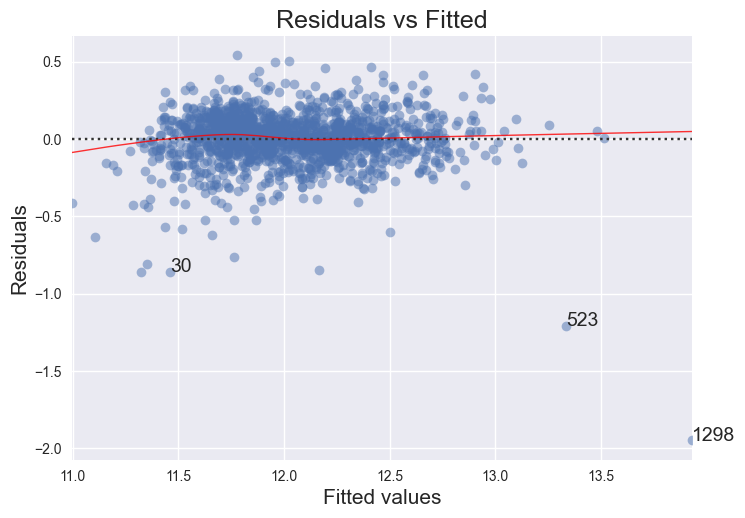

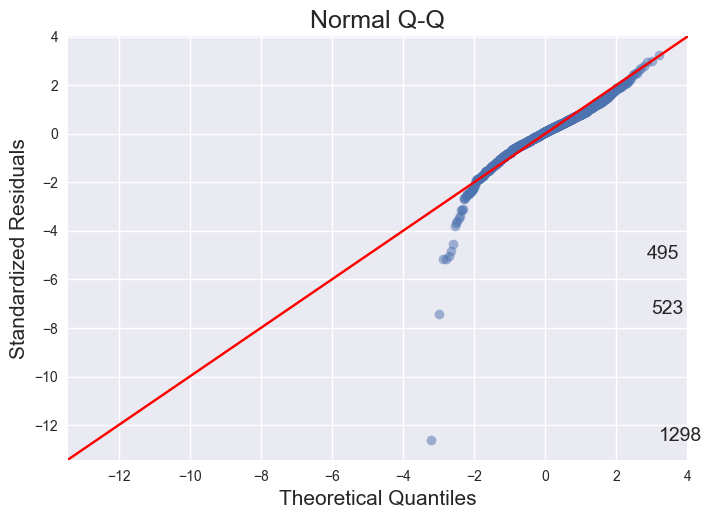

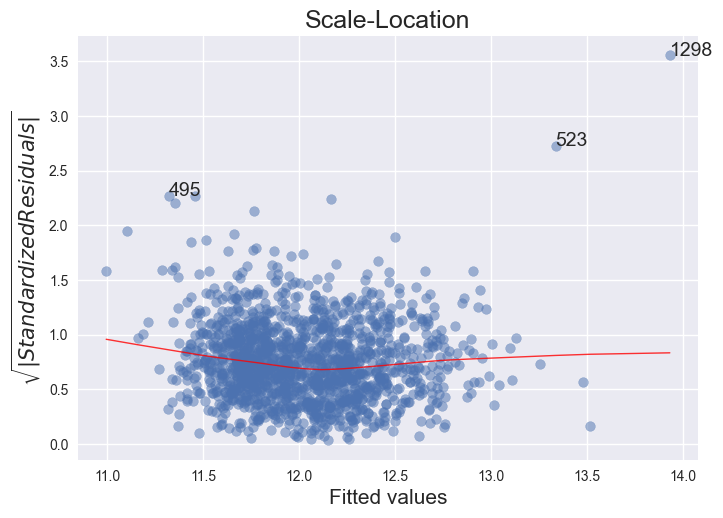

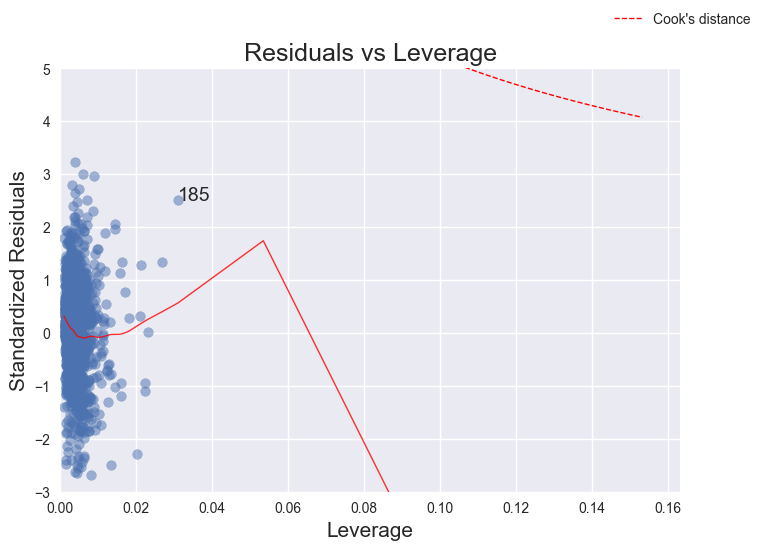

In [41]:
diagnostic_plots(sm.add_constant(X), y)

#### Residuals Analysis

The residuals look free of structure and seems normally distributed around 0. However, we observe some outliers in the residuals. Let's have a look at these data.

In [42]:
print(X[base].iloc[[523, 1298]])

      OverallQual  Neighborhood  GrLivArea  TotalBsmtSF  YearBuilt
523            10     11.712321       4676       3138.0          0
1298           10     11.712321       5642       6110.0          0


Dans la documentation (http://jse.amstat.org/v19n3/decock/DataDocumentation.txt), on peut lire

NOTES SPÉCIALES :
Il y a 5 observations qu'un instructeur peut souhaiter supprimer de l'ensemble de données avant de le donner aux étudiants (un graphique du PRIX DE VENTE en fonction de la ZONE DE VIE GR les indiquera rapidement). Trois d'entre elles sont de véritables valeurs aberrantes (des ventes partielles qui ne représentent probablement pas les valeurs réelles du marché) et deux d'entre elles sont simplement des ventes inhabituelles (de très grandes maisons dont le prix est relativement approprié). Je recommanderais d'éliminer toutes les maisons de plus de 4000 pieds carrés de l'ensemble de données (ce qui élimine ces 5 observations inhabituelles) avant de l'assigner aux étudiants.

Examinons donc les valeurs aberrantes, en particulier dans la colonne **GrLivArea**.



In [43]:
def remove_outliers(data, target, feature):
    
    data_preprocess = data.copy()
    data_preprocess[target.name] = target.copy()
    
    #Compute interquartile range
    q1 = data_preprocess[feature].quantile(0.25)
    q3 = data_preprocess[feature].quantile(0.75)
    
    iqr = q3-q1 
    
    fence_low  = q1 - 1.5 * iqr
    fence_high = q3 + 1.5 * iqr
    
    data_preprocess = data_preprocess.loc[(data_preprocess[feature] > fence_low) & (data_preprocess[feature] < fence_high)]
    
    return data_preprocess[data.columns], data_preprocess[target.name]

Nous allons maintenant exécuter le même code que ci-dessus, sans les valeurs aberrantes

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.842
Model:                            OLS   Adj. R-squared:                  0.842
Method:                 Least Squares   F-statistic:                     1522.
Date:                Wed, 30 Apr 2025   Prob (F-statistic):               0.00
Time:                        13:36:36   Log-Likelihood:                 659.93
No. Observations:                1429   AIC:                            -1308.
Df Residuals:                    1423   BIC:                            -1276.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            7.7556      0.257     30.195   

c:\Users\davgi\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\graphics\gofplots.py:1041: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


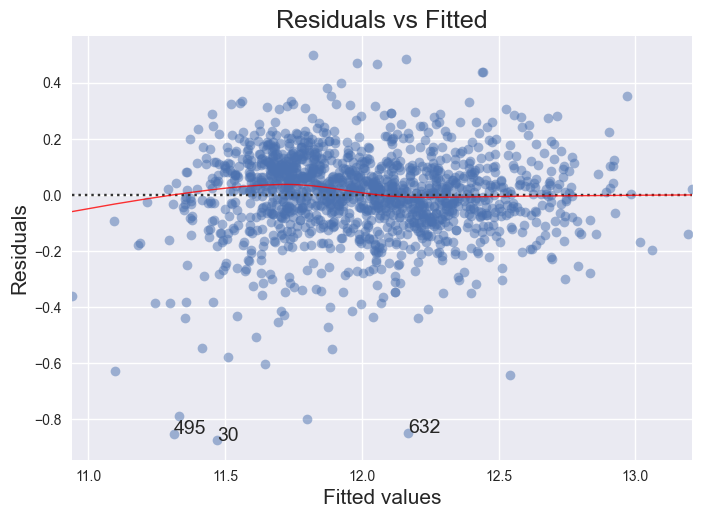

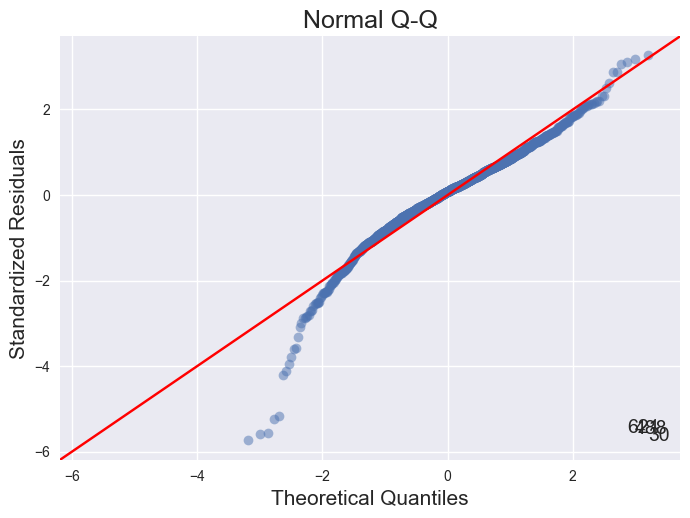

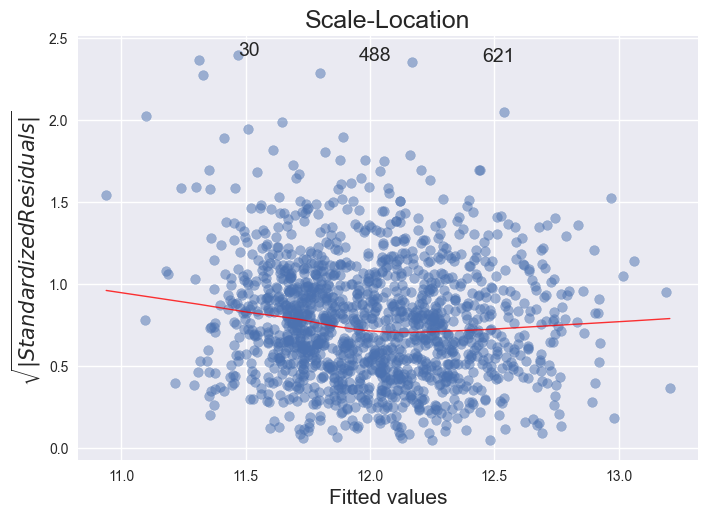

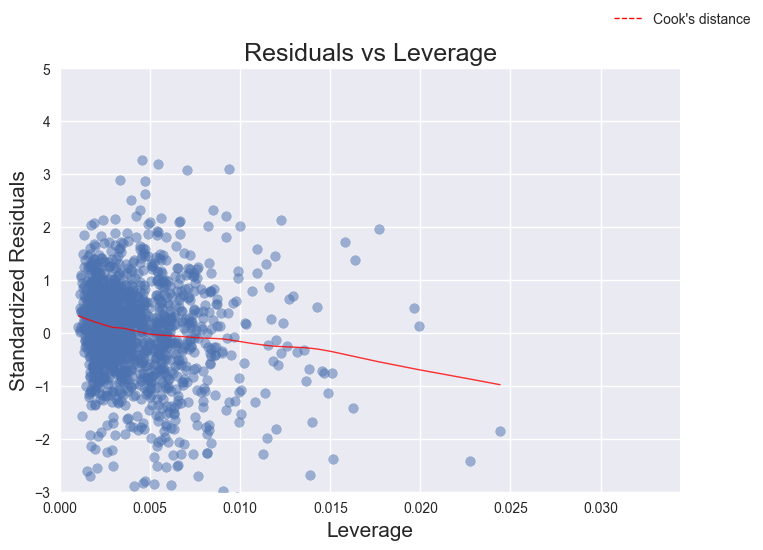

In [44]:
X, y = remove_outliers(X, y, feature = 'GrLivArea')

model = sm.OLS(y, sm.add_constant(X))
res = model.fit()

print(res.summary())

diagnostic_plots(sm.add_constant(X), y)

Ok, c'est beaucoup mieux. Évaluons maintenant notre modèle de base et voyons dans quelle mesure il sera performant sur Kaggle. Pour ce faire, nous utiliserons la méthode **predict**.

In [45]:
y_pred = res.predict(sm.add_constant(X))
print(y_pred.head())

0    12.214534
1    12.081588
2    12.244451
3    12.046219
4    12.620316
dtype: float64


Nous allons visualiser le diagramme de dispersion dans lequel nous comparons la valeur réelle aux valeurs prédites.

In [46]:
def plot_prediction(actual, predicted) :
    
    data = pd.concat([actual, predicted], keys = ['actual', 'predicted'], axis = 1)

    plt.title('Actual vs Predicted')
    sns.regplot(x = 'actual', y = 'predicted', data = data)
    plt.show()

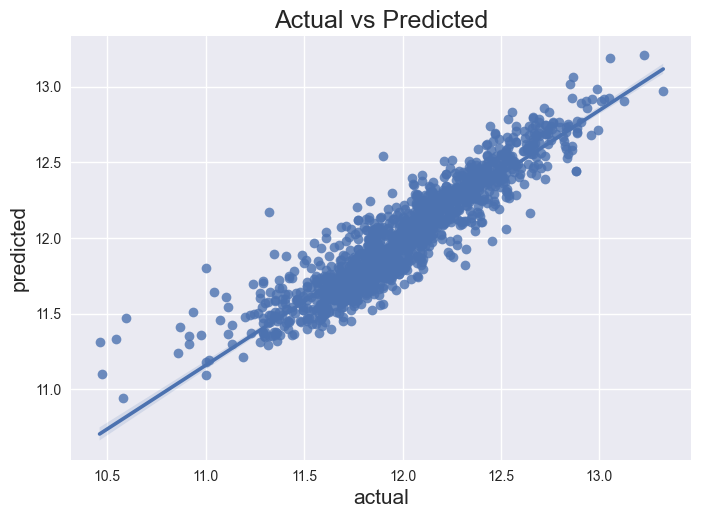

In [47]:
plot_prediction(y, y_pred)

Cela semble fonctionner correctement. Attention au surajustement ici, puisque nous avons prédit et ajusté sur le même ensemble de données. Pour des modèles plus complexes, cela peut être un problème sérieux.

In [52]:
import numpy as np
from sklearn.metrics import mean_squared_log_error

def rmsle(actual, predicted):
    return np.sqrt(mean_squared_log_error(actual, predicted))


In [ ]:
print('Root Mean Square Log Error (RMSLE) :', rmsle(y, y_pred))

Root Mean Square Error (RMSE) : 0.011897571840070703


## 2.3 Baseline Model submission on Kaggle

We use the **predict** method on the validation dataset

In [50]:
y_val = res.predict(sm.add_constant(X_val))

print(y_val.head())

1461    11.663271
1462    11.946171
1463    12.025787
1464    12.101195
1465    12.341289
dtype: float64


We write now our predictions in the _baseline.csv_ file and don't forget to use the inverse function of **np.log1p**, namely **np.expm1**.

In [51]:
submission = pd.DataFrame()
submission['Id'] = y_val.index
submission['SalePrice'] = np.expm1(y_val.values)

submission.to_csv('Data/baseline.csv', index = False)

OSError: Cannot save file into a non-existent directory: 'Data'

<img src="Img/baseline.jpg" width=800 />